# Activation analysis

Reads the per-run artifacts produced by `interp_experiments/run_collect_activations.py` and visualises:

- **Section 1** sanity stats — entropy / answer / stated-confidence distributions, accuracy
- **Section 2** metacognition — does stated confidence track entropy / correctness?
- **Section 3** contrast directions — entropy direction vs stated-confidence direction across layers
- **Section 4** direction movement across model variants — base → instruct → finetuned
- **Section 5** logit lens — what's saved, per-layer answer-token trajectories
- **Section 6** linear probes — direct→direct R², direct→meta transfer R²

Drop one or more run subfolders into `RUN_DIRS` in the next cell and re-run from the top.


In [1]:
# >>>>>>>>> EDIT THIS LIST <<<<<<<<<
# Paste in one or more run subfolders from outputs/activations_directions_logitlens/.
# Order is preserved in the legend; for Section 4 (movement plots) the recommended order is base → instruct → finetuned.
RUN_DIRS = [
    'outputs/activations_directions_logitlens/8b_base_mixed_17173_all_test',
    'outputs/activations_directions_logitlens/8b_instruct_mixed_17173_all_test',
    "outputs/activations_directions_logitlens/8b_20260506-034609_step_300_mixed_17173_all_test",
]
# Optional: override per-run plot labels (None → derive from folder name).
RUN_LABELS = None  # or a list of strings of len(RUN_DIRS)

# Logit-lens flavour to use in Section 5.  "vanilla" reads `*_logit_lens.npz`;
# "tuned" reads `*_tuned_logit_lens.npz` (Belrose et al. 2023, more reliable
# at intermediate layers). If you ran `run_collect_activations.py` with
# LENS_TYPE = "both" (or used `run_apply_tuned_lens.py` retroactively),
# both files will exist and you can flip this knob freely.
LENS_KIND = "vanilla"   # "vanilla" or "tuned"


In [2]:
import json
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Notebook lives in analysis/ — RUN_DIRS are repo-root-relative.
REPO_ROOT = Path('..').resolve() if Path('analyze_activations.ipynb').exists() else Path('.').resolve()
print(f"Repo root: {REPO_ROOT}")


def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()


def _find_prefix(folder: Path) -> str:
    """Each run folder has exactly one *_paired_data.json; the file prefix is what comes before that suffix."""
    candidates = list(folder.glob('*_paired_data.json'))
    if len(candidates) != 1:
        raise RuntimeError(f"Expected 1 *_paired_data.json in {folder}, got {len(candidates)}")
    return str(candidates[0])[:-len('_paired_data.json')]


def _label_from_folder(folder: Path, dataset_name: str) -> str:
    """folder name = '8b_<tag>_<dataset_short>'; returns <tag> as the label."""
    name = folder.name
    dataset_short = Path(dataset_name).stem if dataset_name.endswith('.jsonl') else dataset_name
    suffix = '_' + dataset_short
    if name.startswith('8b_') and name.endswith(suffix):
        return name[3:-len(suffix)]
    return name


@dataclass
class RunData:
    folder: Path
    prefix: str
    label: str
    paired: dict
    results: Optional[dict] = None  # *_entropy_results.json (probe sweep)

    # Lazy NPZ accessors — only loaded when needed. Lens fields are stored as
    # _direct_lens_<kind> / _meta_lens_<kind> so 'vanilla' and 'tuned' caches
    # don't collide; see direct_lens() / meta_lens() below.
    _entropy_dirs: Optional[dict] = None
    _ec_dirs: Optional[dict] = None        # entropy_contrast
    _sc_dirs: Optional[dict] = None        # stated_confidence_contrast
    _mc_dirs: Optional[dict] = None        # mc_answer

    @property
    def config(self): return self.paired.get('config', {}) or {}

    def _load_npz(self, suffix):
        path = Path(f"{self.prefix}_{suffix}.npz")
        if not path.exists():
            return None
        with np.load(path, allow_pickle=True) as f:
            return {k: f[k] for k in f.files}

    def direct_lens(self, kind=None):
        """Return the direct-prompt logit lens NPZ as a dict.

        kind: 'vanilla' (logit_lens.npz), 'tuned' (tuned_logit_lens.npz),
              or None → consult the global LENS_KIND.
        """
        kind = kind or LENS_KIND
        suffix = 'direct_logit_lens' if kind == 'vanilla' else 'direct_tuned_logit_lens'
        attr = f'_direct_lens_{kind}'
        cached = getattr(self, attr, None)
        if cached is None:
            cached = self._load_npz(suffix)
            setattr(self, attr, cached)
        return cached

    def meta_lens(self, kind=None):
        kind = kind or LENS_KIND
        suffix = 'meta_logit_lens' if kind == 'vanilla' else 'meta_tuned_logit_lens'
        attr = f'_meta_lens_{kind}'
        cached = getattr(self, attr, None)
        if cached is None:
            cached = self._load_npz(suffix)
            setattr(self, attr, cached)
        return cached

    def entropy_probe_dirs(self):
        if self._entropy_dirs is None:
            self._entropy_dirs = self._load_npz('entropy_directions')
        return self._entropy_dirs

    def entropy_contrast_dirs(self):
        if self._ec_dirs is None:
            self._ec_dirs = self._load_npz('entropy_contrast_directions')
        return self._ec_dirs

    def stated_conf_contrast_dirs(self):
        if self._sc_dirs is None:
            self._sc_dirs = self._load_npz('stated_confidence_contrast_directions')
        return self._sc_dirs

    def mc_answer_dirs(self):
        if self._mc_dirs is None:
            self._mc_dirs = self._load_npz('mc_answer_directions')
        return self._mc_dirs


def load_run(folder, label=None):
    folder = _resolve(folder)
    prefix = _find_prefix(folder)
    paired = json.load(open(f"{prefix}_paired_data.json"))

    # Probe results — entropy_results.json by default; runner names it after the chosen METRIC.
    metric = (paired.get('config') or {}).get('metric', 'entropy')
    rpath = Path(f"{prefix}_{metric}_results.json")
    results = json.load(open(rpath)) if rpath.exists() else None

    if label is None:
        label = _label_from_folder(folder, (paired.get('config') or {}).get('dataset_name', folder.name))
    return RunData(folder=folder, prefix=prefix, label=label, paired=paired, results=results)


# Load all
labels = RUN_LABELS if RUN_LABELS else [None] * len(RUN_DIRS)
RUNS: List[RunData] = [load_run(d, l) for d, l in zip(RUN_DIRS, labels)]

# Compact label for the lone finetuned run. _label_from_folder returns the
# adapter's date-time + step (e.g. '20260506-034609_step_300') so multiple
# finetuned runs stay distinguishable; if only ONE finetuned run is loaded,
# collapse its label to plain 'finetuned' to match the base / instruct convention.
# Skips the relabel when the user supplied an explicit RUN_LABELS override.
if not RUN_LABELS:
    finetuned_idx = [i for i, r in enumerate(RUNS) if r.label not in ('base', 'instruct')]
    if len(finetuned_idx) == 1:
        RUNS[finetuned_idx[0]].label = 'finetuned'

# Canonical run ordering: base → instruct → finetuned → (other variants alphabetical).
# Every plot below iterates over RUNS in this order, so the legend / x-axis stays consistent.
# Skipped when the user supplied an explicit RUN_LABELS — their order wins.
if not RUN_LABELS:
    def _order_key(label):
        if label == 'base':      return (0, '')
        if label == 'instruct':  return (1, '')
        if label == 'finetuned': return (2, '')
        return (3, label)
    RUNS.sort(key=lambda r: _order_key(r.label))

print(f"Loaded {len(RUNS)} run(s):")
for r in RUNS:
    cfg = r.config
    print(f"  {r.label:35s}  model={cfg.get('base_model_name','?')}  adapter={cfg.get('model_name','?').split('/')[-1] if cfg.get('model_name','?') != cfg.get('base_model_name','?') else '(none)'}")
    print(f"  {'':35s}  dataset={cfg.get('dataset_name','?')}  n={cfg.get('num_questions','?')}  meta_task={cfg.get('meta_task','?')}  scale={cfg.get('confidence_scale','?')}  metric={cfg.get('metric','?')}")


Repo root: /workspace/projects/metacognition
Loaded 3 run(s):
  base                                 model=meta-llama/Llama-3.1-8B  adapter=(none)
                                       dataset=data/mixed_17173_all_test.jsonl  n=1800  meta_task=confidence  scale=numeric  metric=entropy
  instruct                             model=meta-llama/Llama-3.1-8B-Instruct  adapter=(none)
                                       dataset=data/mixed_17173_all_test.jsonl  n=1800  meta_task=confidence  scale=numeric  metric=entropy
  finetuned                            model=meta-llama/Llama-3.1-8B-Instruct  adapter=20260506-034609_delegate_at_mixed_17173_all_top_prob_tm0.7_tau0.05_2e_ckpt_step_300
                                       dataset=data/mixed_17173_all_test.jsonl  n=1800  meta_task=confidence  scale=numeric  metric=entropy


---
## Section 1 — Summary statistics & sanity checks

Per-run distributions: MC entropy, predicted-answer (A/B/C/D) counts, stated-confidence digit, soft stated confidence, and overall direct accuracy.

In [3]:
# Headline accuracy + meta-response stats per run.
import pandas as pd

rows = []
for r in RUNS:
    pd_ = r.paired
    n = len(pd_['is_correct'])
    acc = float(np.mean(pd_['is_correct']))
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    sc = np.asarray(pd_['stated_confidence_numeric'], dtype=float)
    sc_valid = sc[~np.isnan(sc)]
    rows.append({
        'run': r.label, 'n': n, 'accuracy': acc,
        'entropy_mean': ent.mean(), 'entropy_std': ent.std(),
        'stated_conf_mean': float(np.nanmean(sc)),
        'stated_conf_std':  float(np.nanstd(sc)),
        'meta_responses_unique': len(set(pd_['meta_responses'])),
    })
df_summary = pd.DataFrame(rows)
df_summary


,run,n,accuracy,entropy_mean,entropy_std,stated_conf_mean,stated_conf_std,meta_responses_unique
0,base,1713,0.542323,0.869342,0.461836,0.509603,0.085180,7
1,instruct,1713,0.548161,0.615077,0.472497,0.536391,0.173866,7
2,finetuned,1713,0.568593,0.601719,0.461099,0.612780,0.186078,8


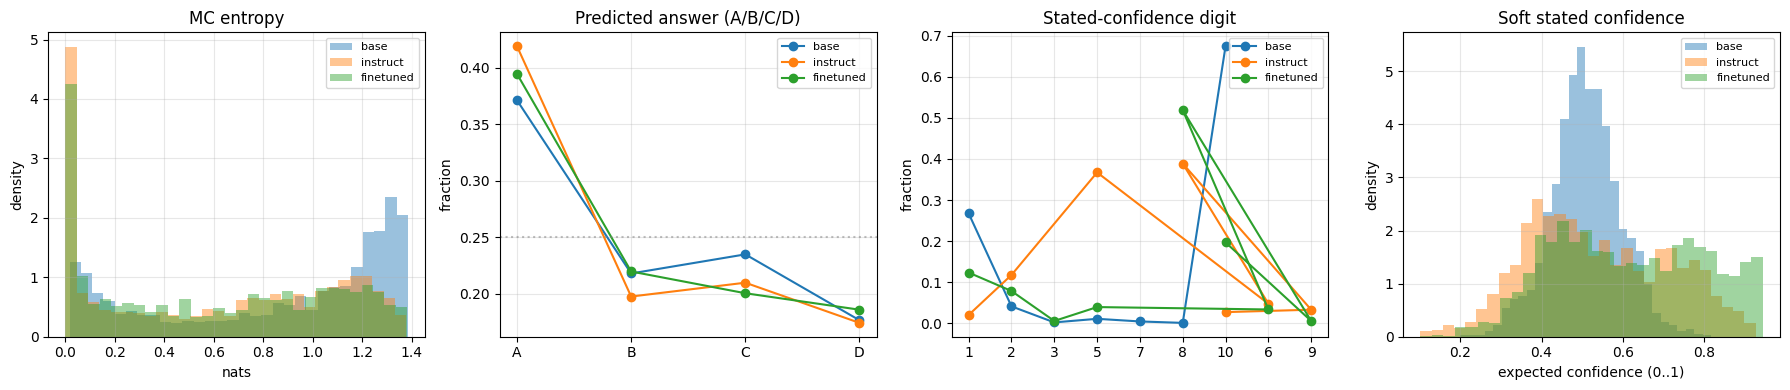


Distribution summary (n questions per run):
  [base]
    entropy:        mean=0.869  std=0.462  p25=0.429  p75=1.266
    answer A/B/C/D: ['37.1%', '21.8%', '23.5%', '17.6%']
    meta digits:    {'1': '26.7%', '2': '4.1%', '3': '0.2%', '5': '1.1%', '7': '0.4%', '8': '0.1%', '10': '67.5%'}
    soft stated:    mean=0.510  std=0.085  p25=0.460  p75=0.563
  [instruct]
    entropy:        mean=0.615  std=0.472  p25=0.079  p75=1.064
    answer A/B/C/D: ['41.9%', '19.7%', '21.0%', '17.4%']
    meta digits:    {'1': '2.0%', '2': '11.7%', '5': '36.7%', '6': '4.7%', '8': '38.9%', '9': '3.3%', '10': '2.7%'}
    soft stated:    mean=0.536  std=0.174  p25=0.400  p75=0.686
  [finetuned]
    entropy:        mean=0.602  std=0.461  p25=0.108  p75=1.035
    answer A/B/C/D: ['39.5%', '21.9%', '20.0%', '18.6%']
    meta digits:    {'1': '12.3%', '2': '7.8%', '3': '0.5%', '5': '3.9%', '6': '3.3%', '8': '51.9%', '9': '0.5%', '10': '19.7%'}
    soft stated:    mean=0.613  std=0.186  p25=0.459  p75=0.772


In [4]:
# Distributions: 4 panels (entropy, MC-answer, stated-confidence digit, soft stated confidence)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
LETTERS = ['A','B','C','D']

for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    axes[0].hist(ent, bins=30, alpha=0.45, density=True, label=r.label)

    direct_resp = pd_['direct_responses']
    counts = [direct_resp.count(L) for L in LETTERS]
    axes[1].plot(LETTERS, np.array(counts) / max(len(direct_resp), 1), 'o-', label=r.label)

    meta_resp = [str(x) for x in pd_['meta_responses']]
    # Numeric sort: '1','2',...,'10' (NOT lexical '1','10','2',...).
    digits = sorted({d for d in meta_resp}, key=lambda x: int(x) if x.isdigit() else 999)
    counts_d = [meta_resp.count(d) for d in digits]
    axes[2].plot(digits, np.array(counts_d) / max(len(meta_resp), 1), 'o-', label=r.label)

    sc = np.asarray(pd_['stated_confidence_numeric'], dtype=float)
    sc = sc[~np.isnan(sc)]
    axes[3].hist(sc, bins=30, alpha=0.45, density=True, label=r.label)

axes[0].set_title('MC entropy'); axes[0].set_xlabel('nats'); axes[0].set_ylabel('density')
axes[1].set_title('Predicted answer (A/B/C/D)'); axes[1].set_ylabel('fraction'); axes[1].axhline(0.25, color='gray', linestyle=':', alpha=0.5)
axes[2].set_title('Stated-confidence digit'); axes[2].set_ylabel('fraction')
axes[3].set_title('Soft stated confidence'); axes[3].set_xlabel('expected confidence (0..1)'); axes[3].set_ylabel('density')
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- text output (numbers visible without parsing the figure) ----
print(f"\nDistribution summary (n questions per run):")
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    sc_v = sc[~np.isnan(sc)]
    direct_resp = pd_['direct_responses']
    meta_resp = [str(x) for x in pd_['meta_responses']]
    answer_dist = {L: direct_resp.count(L)/len(direct_resp) for L in 'ABCD'}
    digit_dist  = {d: meta_resp.count(d)/len(meta_resp) for d in sorted(set(meta_resp), key=lambda x: int(x) if x.isdigit() else 999)}
    print(f"  [{r.label}]")
    print(f"    entropy:        mean={ent.mean():.3f}  std={ent.std():.3f}  "
          f"p25={np.percentile(ent,25):.3f}  p75={np.percentile(ent,75):.3f}")
    print(f"    answer A/B/C/D: {[f'{answer_dist[L]:.1%}' for L in 'ABCD']}")
    print(f"    meta digits:    {dict((d, f'{v:.1%}') for d,v in digit_dist.items())}")
    print(f"    soft stated:    mean={sc_v.mean():.3f}  std={sc_v.std():.3f}  "
          f"p25={np.percentile(sc_v,25):.3f}  p75={np.percentile(sc_v,75):.3f}")


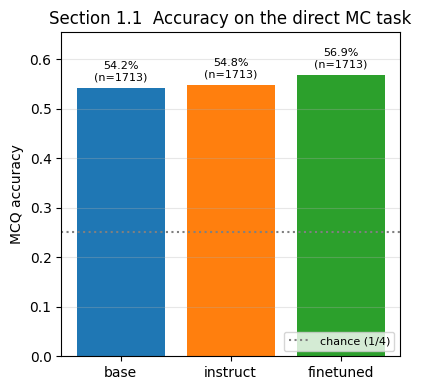


Accuracy per run:
  base                           0.5423  (n=1713)
  instruct                       0.5482  (n=1713)
  finetuned                      0.5686  (n=1713)


In [5]:
# Section 1.1  Accuracy comparison across runs (single bar chart for fast eyeballing).
fig, ax = plt.subplots(figsize=(max(4, 1.4 * len(RUNS)), 4))
labels = [r.label for r in RUNS]
accs = [float(np.mean(r.paired['is_correct'])) for r in RUNS]
ns   = [len(r.paired['is_correct']) for r in RUNS]
bars = ax.bar(labels, accs, color=[plt.cm.tab10(i) for i in range(len(RUNS))])
for bar, acc, n in zip(bars, accs, ns):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
            f"{acc:.1%}\n(n={n})", ha='center', va='bottom', fontsize=8)
ax.axhline(0.25, color='gray', linestyle=':', label='chance (1/4)')
ax.set_ylim(0, max(accs) * 1.15 if accs else 1)
ax.set_ylabel('MCQ accuracy')
ax.set_title('Section 1.1  Accuracy on the direct MC task')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nAccuracy per run:")
for lab, a, n in zip(labels, accs, ns):
    print(f"  {lab:30s} {a:.4f}  (n={n})")


---
## Section 2 — Metacognition

Does the model's verbalised confidence track its internal uncertainty?

- Spearman ρ(entropy, stated_confidence) — negative ρ means stated confidence falls as entropy rises (the introspective direction).
- Reliability diagram — empirical accuracy in stated-confidence bins vs the diagonal (perfect calibration).
- Entropy vs accuracy — internal-uncertainty ceiling. Stated-confidence AUROC can't exceed AUROC(−entropy, correct).

In [6]:
# Spearman + key correlations per run, plus ECE/Brier on stated confidence.
def _ece(conf, correct, n_bins=10):
    conf = np.asarray(conf, float); correct = np.asarray(correct, float)
    m = ~np.isnan(conf) & ~np.isnan(correct)
    conf, correct = conf[m], correct[m]
    if len(conf) == 0: return float('nan')
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(conf, edges) - 1, 0, n_bins - 1)
    n = len(conf); ece = 0.0
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() == 0: continue
        ece += (sel.sum() / n) * abs(conf[sel].mean() - correct[sel].mean())
    return ece

def _brier(conf, correct):
    conf = np.asarray(conf, float); correct = np.asarray(correct, float)
    m = ~np.isnan(conf) & ~np.isnan(correct)
    if m.sum() == 0: return float('nan')
    return float(np.mean((conf[m] - correct[m])**2))

try:
    from sklearn.metrics import roc_auc_score
    _have_sk = True
except ImportError:
    _have_sk = False

rows = []
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    correct = np.asarray(pd_['is_correct'], float)
    m = ~np.isnan(ent) & ~np.isnan(sc) & ~np.isnan(correct)
    rho_es, p_es = spearmanr(ent[m], sc[m]) if m.sum() > 10 else (float('nan'), float('nan'))
    rho_sc_corr, _ = spearmanr(sc[m], correct[m]) if m.sum() > 10 else (float('nan'), float('nan'))
    auroc_neg_ent = roc_auc_score(correct[m].astype(int), -ent[m]) if (_have_sk and m.sum() > 10 and len(set(correct[m])) > 1) else float('nan')
    auroc_sc = roc_auc_score(correct[m].astype(int), sc[m]) if (_have_sk and m.sum() > 10 and len(set(correct[m])) > 1) else float('nan')
    rows.append({
        'run': r.label,
        'rho(entropy, stated_conf)': rho_es,
        'rho(stated_conf, correct)': rho_sc_corr,
        'AUROC(-entropy, correct)': auroc_neg_ent,
        'AUROC(stated_conf, correct)': auroc_sc,
        'ECE(stated_conf)': _ece(sc, correct),
        'Brier(stated_conf)': _brier(sc, correct),
    })
df_meta = pd.DataFrame(rows).round(4)
df_meta


,run,"rho(entropy, stated_conf)","rho(stated_conf, correct)","AUROC(-entropy, correct)","AUROC(stated_conf, correct)",ECE(stated_conf),Brier(stated_conf)
0,base,-0.3316,0.1554,0.7679,0.5900,0.0429,0.2433
1,instruct,-0.6355,0.2848,0.7522,0.6652,0.0770,0.2265
2,finetuned,-0.7423,0.3490,0.7588,0.7034,0.0742,0.2172


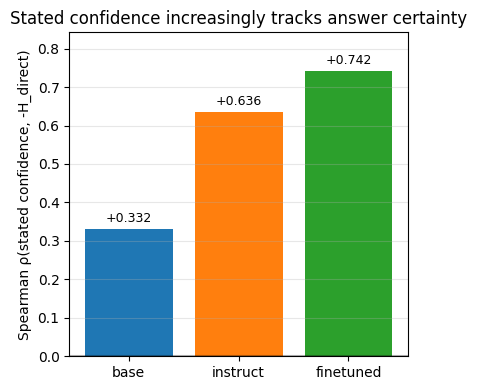


Spearman ρ(-entropy, stated_confidence) per run:
  base                           +0.3316
  instruct                       +0.6355
  finetuned                      +0.7423


In [7]:
# Spearman ρ(-entropy, stated_confidence) across runs.
# This is THE headline metacognition stat: positive ρ means stated confidence
# rises as internal entropy falls (the introspection-consistent direction).
# Same number as `df_meta['rho(entropy, stated_conf)']` above with the sign flipped
# — we plot ρ(-entropy, ...) so "more positive = better metacognition" is the visual
# convention, easier to compare across models.
fig, ax = plt.subplots(figsize=(max(4, 1.4 * len(RUNS)), 4))
labels = [r.label for r in RUNS]
rhos = []
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    m = ~np.isnan(ent) & ~np.isnan(sc)
    if m.sum() < 10:
        rhos.append(np.nan); continue
    rho, _ = spearmanr(-ent[m], sc[m])
    rhos.append(float(rho))
bars = ax.bar(labels, rhos, color=[plt.cm.tab10(i) for i in range(len(RUNS))])
for bar, rho in zip(bars, rhos):
    if not np.isnan(rho):
        ax.text(bar.get_x() + bar.get_width() / 2, rho + (0.01 if rho >= 0 else -0.03),
                f"{rho:+.3f}", ha='center',
                va='bottom' if rho >= 0 else 'top', fontsize=9)
ax.axhline(0, color='black', alpha=0.3)
ax.set_ylim(min(0, min([r for r in rhos if not np.isnan(r)] or [0]) - 0.05),
            max([r for r in rhos if not np.isnan(r)] or [0.5]) + 0.1)
ax.set_ylabel('Spearman ρ(stated confidence, -H_direct)')
ax.set_title('Stated confidence increasingly tracks answer certainty')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nSpearman ρ(-entropy, stated_confidence) per run:")
for lab, rho in zip(labels, rhos):
    print(f"  {lab:30s} {rho:+.4f}" if not np.isnan(rho) else f"  {lab:30s} (insufficient data)")


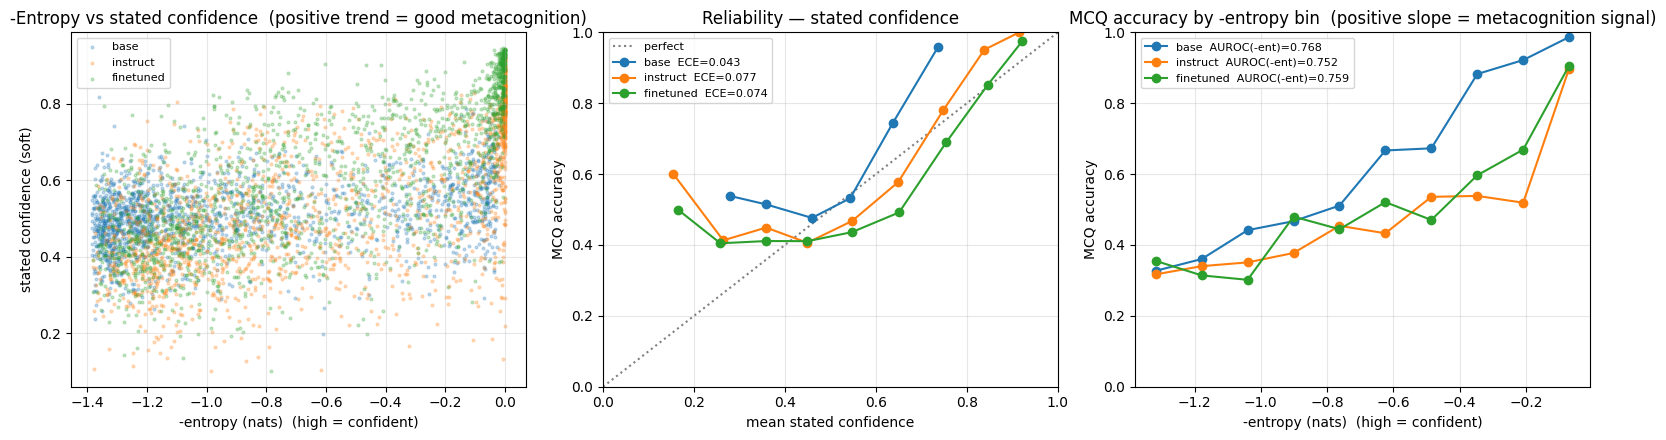


Reliability bins on stated confidence (mean_conf, accuracy, n) per run:
  [base]  ECE=0.0429  Brier=0.2433
    bin [0.2,0.3]: mean_conf=0.279  acc=0.538  n=13
    bin [0.3,0.4]: mean_conf=0.359  acc=0.514  n=140
    bin [0.4,0.5]: mean_conf=0.459  acc=0.476  n=634
    bin [0.5,0.6]: mean_conf=0.543  acc=0.532  n=688
    bin [0.6,0.7]: mean_conf=0.637  acc=0.744  n=211
    bin [0.7,0.8]: mean_conf=0.737  acc=0.960  n=25
  [instruct]  ECE=0.0770  Brier=0.2265
    bin [0.1,0.2]: mean_conf=0.155  acc=0.600  n=25
    bin [0.2,0.3]: mean_conf=0.264  acc=0.413  n=92
    bin [0.3,0.4]: mean_conf=0.359  acc=0.449  n=314
    bin [0.4,0.5]: mean_conf=0.449  acc=0.406  n=384
    bin [0.5,0.6]: mean_conf=0.548  acc=0.468  n=278
    bin [0.6,0.7]: mean_conf=0.649  acc=0.577  n=239
    bin [0.7,0.8]: mean_conf=0.748  acc=0.780  n=246
    bin [0.8,0.9]: mean_conf=0.839  acc=0.951  n=123
    bin [0.9,1.0]: mean_conf=0.915  acc=1.000  n=12
  [finetuned]  ECE=0.0742  Brier=0.2172
    bin [0.1,0.2]: mean

In [8]:
# Three diagnostic panels (overlaid across runs):
#   (1) entropy vs stated confidence scatter — one panel per run, green=correct
#   (2) reliability diagram on stated confidence
#   (3) accuracy by entropy bin

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) scatter, faceted via inset would clutter — so plot all on one panel with run color, transparent
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    m = ~np.isnan(ent) & ~np.isnan(sc)
    # -entropy on x: positive correlation reads metacognition-aligned.
    axes[0].scatter(-ent[m], sc[m], s=4, alpha=0.25, label=r.label)
axes[0].set_xlabel('-entropy (nats)  (high = confident)'); axes[0].set_ylabel('stated confidence (soft)')
axes[0].set_title('-Entropy vs stated confidence  (positive trend = good metacognition)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# (2) reliability diagram on stated conf
axes[1].plot([0,1],[0,1], color='gray', linestyle=':', label='perfect')
for r in RUNS:
    pd_ = r.paired
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    correct = np.asarray(pd_['is_correct'], float)
    m = ~np.isnan(sc) & ~np.isnan(correct)
    sc, correct = sc[m], correct[m]
    edges = np.linspace(0, 1, 11)
    idx = np.clip(np.digitize(sc, edges) - 1, 0, 9)
    xs, ys = [], []
    for b in range(10):
        sel = idx == b
        if sel.sum() < 3: continue
        xs.append(sc[sel].mean()); ys.append(correct[sel].mean())
    axes[1].plot(xs, ys, 'o-', label=f'{r.label}  ECE={_ece(sc, correct):.3f}')
axes[1].set_xlabel('mean stated confidence'); axes[1].set_ylabel('MCQ accuracy')
axes[1].set_title('Reliability — stated confidence')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

# (3) accuracy in entropy bins
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    correct = np.asarray(pd_['is_correct'], float)
    # Bin on -entropy (high-confidence → high-accuracy reads as positive slope).
    edges = np.linspace(-np.log(4), 0, 11)
    mids = 0.5 * (edges[:-1] + edges[1:])
    idx = np.clip(np.digitize(-ent, edges) - 1, 0, 9)
    xs, ys = [], []
    for b in range(10):
        sel = idx == b
        if sel.sum() < 3: continue
        xs.append(mids[b]); ys.append(correct[sel].mean())
    auc = ''
    if _have_sk and len(set(correct)) > 1:
        auc = f'  AUROC(-ent)={roc_auc_score(correct.astype(int), -ent):.3f}'
    axes[2].plot(xs, ys, 'o-', label=f'{r.label}{auc}')
axes[2].set_xlabel('-entropy (nats)  (high = confident)'); axes[2].set_ylabel('MCQ accuracy')
axes[2].set_title('MCQ accuracy by -entropy bin  (positive slope = metacognition signal)')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nReliability bins on stated confidence (mean_conf, accuracy, n) per run:")
for r in RUNS:
    pd_ = r.paired
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    correct = np.asarray(pd_['is_correct'], float)
    m = ~np.isnan(sc) & ~np.isnan(correct)
    sc, correct = sc[m], correct[m]
    edges = np.linspace(0, 1, 11)
    idx = np.clip(np.digitize(sc, edges) - 1, 0, 9)
    print(f"  [{r.label}]  ECE={_ece(sc, correct):.4f}  Brier={_brier(sc, correct):.4f}")
    for b in range(10):
        sel = idx == b
        if sel.sum() < 3: continue
        print(f"    bin [{edges[b]:.1f},{edges[b+1]:.1f}]: mean_conf={sc[sel].mean():.3f}  acc={correct[sel].mean():.3f}  n={int(sel.sum())}")

print("\nMCQ accuracy in -entropy bins (high -entropy = confident):")
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    correct = np.asarray(pd_['is_correct'], float)
    edges = np.linspace(-np.log(4), 0, 11)
    idx = np.clip(np.digitize(-ent, edges) - 1, 0, 9)
    auc = ''
    if _have_sk and len(set(correct)) > 1:
        auc = f'  AUROC(-ent)={roc_auc_score(correct.astype(int), -ent):.4f}'
    print(f"  [{r.label}]{auc}")
    for b in range(10):
        sel = idx == b
        if sel.sum() < 3: continue
        mid = 0.5 * (edges[b] + edges[b+1])
        print(f"    -entropy~{mid:+.2f}: acc={correct[sel].mean():.3f}  n={int(sel.sum())}")


---
## Section 3 — Contrast directions

Two **mean-difference** directions per layer per run, both computed from the runner's saved activations:

- **Entropy contrast** — `mean(direct_acts[high entropy]) − mean(direct_acts[low entropy])`. Direct (MC) prompt activations.
- **Stated-confidence contrast** — `mean(meta_acts[high stated conf]) − mean(meta_acts[low stated conf])`. Meta (confidence prompt) activations.

The three plots below probe different facets:

- **Section 3.1** — does the model use the *same* axis to encode MC uncertainty and stated confidence?
- **Section 3.2** — does the simple mean-diff direction agree with the Ridge-probe direction on the same target?
- **Section 3.3** — is each contrast direction smooth across layers (sanity), or is it noisily different layer-to-layer?


### Section 3.1  Cosine similarity between entropy contrast and stated-confidence contrast

The headline plot for the introspection question. For each layer:

- The **entropy direction** is built from MC-prompt activations and tells us how the residual stream shifts when the model is uncertain about an answer.
- The **stated-confidence direction** is built from META-prompt activations and tells us how the residual stream shifts when the model says it's confident vs not.

If the model uses the *same internal axis* for both — **introspection signature**: cosine close to 1 means "the activation pattern that encodes 'I'm uncertain about this answer' is the same one that encodes 'I'm not very confident in my answer'", just elicited from two different prompt framings.

If the cosine is near 0 across layers, the two confidence concepts live on different axes and stated confidence is being computed from something *other* than the model's own MC uncertainty. If it's strongly negative, the directions are anti-aligned (which would be very surprising and probably suggest a sign convention mismatch in one of the contrast computations).


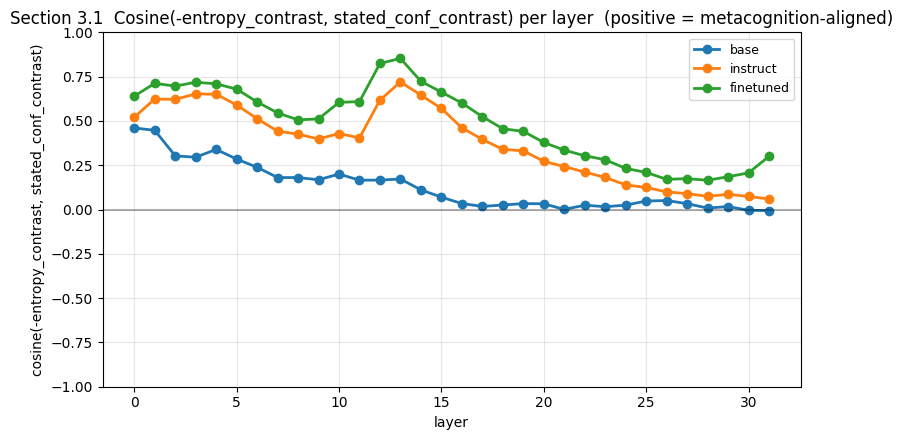


Per-layer cosine(-entropy_contrast, stated_conf_contrast)  [positive = metacognition-aligned]:
  [base]  peak |cos|=+0.4602 at layer 0  mean=+0.1293  range=[-0.0061, +0.4602]
    per-layer: L0=+0.460  L1=+0.447  L2=+0.303  L3=+0.295  L4=+0.339  L5=+0.285  L6=+0.238  L7=+0.181  L8=+0.180  L9=+0.168  L10=+0.200  L11=+0.166  L12=+0.166  L13=+0.172  L14=+0.111  L15=+0.070  L16=+0.034  L17=+0.018  L18=+0.025  L19=+0.033  L20=+0.032  L21=+0.001  L22=+0.024  L23=+0.016  L24=+0.025  L25=+0.048  L26=+0.051  L27=+0.033  L28=+0.008  L29=+0.017  L30=-0.004  L31=-0.006
  [instruct]  peak |cos|=+0.7198 at layer 13  mean=+0.3752  range=[+0.0594, +0.7198]
    per-layer: L0=+0.521  L1=+0.623  L2=+0.622  L3=+0.652  L4=+0.651  L5=+0.590  L6=+0.513  L7=+0.442  L8=+0.425  L9=+0.398  L10=+0.429  L11=+0.404  L12=+0.618  L13=+0.720  L14=+0.646  L15=+0.571  L16=+0.461  L17=+0.396  L18=+0.340  L19=+0.331  L20=+0.272  L21=+0.242  L22=+0.211  L23=+0.181  L24=+0.139  L25=+0.125  L26=+0.099  L27=+0.090  L28=+0.074

In [9]:
def _stack_layers(direction_npz):
    """Return (n_layers, hidden_dim) array of layer directions, sorted by layer index."""
    if direction_npz is None: return None
    layer_keys = sorted([k for k in direction_npz if k.startswith('layer_')], key=lambda x: int(x.split('_')[1]))
    return np.stack([direction_npz[k].astype(np.float32) for k in layer_keys], axis=0), [int(k.split('_')[1]) for k in layer_keys]


def _cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


# Cosine similarity per layer between entropy-contrast and stated-confidence-contrast.
fig, ax = plt.subplots(figsize=(8, 4.5))
for r in RUNS:
    ec, sc = r.entropy_contrast_dirs(), r.stated_conf_contrast_dirs()
    if ec is None or sc is None:
        print(f"{r.label}: skipping — missing entropy_contrast or stated_confidence_contrast"); continue
    ec_arr, layers = _stack_layers(ec)
    sc_arr, _ = _stack_layers(sc)
    # Flip entropy sign so 'metacognition-aligned' reads as positive cosine.
    # entropy_contrast points low-confidence ↑; -entropy_contrast points high-confidence ↑.
    cos = np.array([_cosine(-ec_arr[i], sc_arr[i]) for i in range(len(layers))])
    ax.plot(layers, cos, 'o-', linewidth=2, label=r.label)
ax.axhline(0, color='black', alpha=0.3)
ax.set_xlabel('layer'); ax.set_ylabel('cosine(-entropy_contrast, stated_conf_contrast)')
ax.set_title('Section 3.1  Cosine(-entropy_contrast, stated_conf_contrast) per layer  (positive = metacognition-aligned)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(-1, 1)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nPer-layer cosine(-entropy_contrast, stated_conf_contrast)  [positive = metacognition-aligned]:")
for r in RUNS:
    ec, sc = r.entropy_contrast_dirs(), r.stated_conf_contrast_dirs()
    if ec is None or sc is None:
        print(f"  [{r.label}] missing direction file"); continue
    ec_arr, layers = _stack_layers(ec)
    sc_arr, _ = _stack_layers(sc)
    cos = np.array([_cosine(-ec_arr[k], sc_arr[k]) for k in range(len(layers))])
    peak_l = int(layers[int(np.argmax(np.abs(cos)))])
    print(f"  [{r.label}]  peak |cos|={cos[layers.index(peak_l)]:+.4f} at layer {peak_l}  "
          f"mean={cos.mean():+.4f}  range=[{cos.min():+.4f}, {cos.max():+.4f}]")
    print(f"    per-layer: " + "  ".join(f"L{l}={c:+.3f}" for l, c in zip(layers, cos)))


### Section 3.2  Do mean-diff and Ridge-probe agree on the entropy direction?

We have **two** ways to extract "the entropy direction" from direct activations:

- **Mean-diff (contrast)** — the centroid difference `mean(X[high entropy]) − mean(X[low entropy])`. Drops the middle 50%, no scaling, no regularisation.
- **Ridge probe** — fits `argmin_β ||Xβ − entropy||² + α‖β‖²` over **all** rows in standardised + PCA-reduced space, then maps the coefficients back to original activation space (divides by `scaler.scale_` and unit-normalises).

If they're picking up the same underlying signal, the layer-wise cosine should be moderately positive. **Random vectors in 4096-dim space have cosine ≈ 0**, so a value of 0.2–0.4 here is *real agreement*, not noise — but it's far from 1.

**Why isn't it ≈ 1?** Because the two methods optimise different objectives in different feature spaces:

1. **Different objectives.** Mean-diff fits two centroids; Ridge fits a continuous predictor over all questions including the middle 50%. The middle data pulls the Ridge β in directions the centroids don't see.
2. **Standardisation rescales features.** Ridge fits in standardised space; the inverse map `β / σ` then *amplifies* low-variance features in the saved direction. Mean-diff does no rescaling, so high-variance features dominate it. The two methods literally weight features differently.
3. **PCA truncation.** Ridge fits in 100-dim PCA space (the top variance directions). Mean-diff uses the full 4096-dim space. They're not constrained to find the same axis.
4. **Cosine is brutal in high dimensions.** 0.3 cosine in 4096-dim space corresponds to a substantial shared subspace. The methods are *correlated* readouts, not identical.

**Takeaway.** Cosine 0.2–0.4 across most layers means the two methods broadly agree (not just chance), but they're complementary readouts, not interchangeable. For *steering* experiments, use mean-diff (the centroid shift is the natural delta). For *predictive monitoring* (what's the model's entropy from this activation?), use the Ridge probe. They will give different but related answers.

If Section 3.2 had shown cosine **≈ 0** across all layers, *that* would be alarming — the two methods would be reading completely different signals. 0.2–0.4 is the expected, healthy regime.


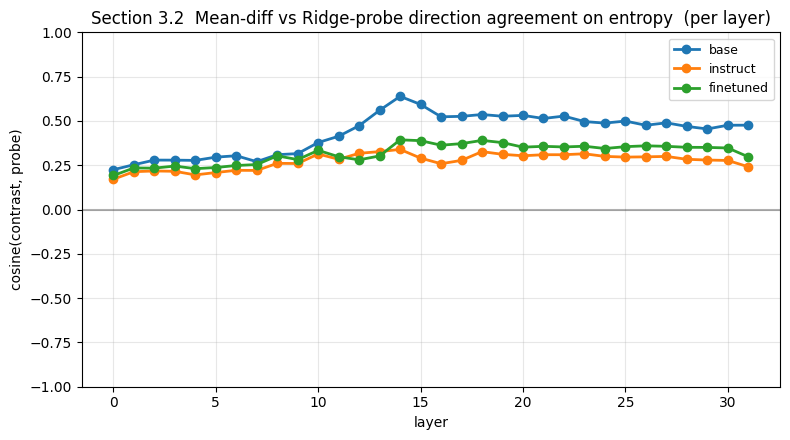


Per-layer cosine(entropy_contrast, entropy_probe):
  [base]  mean=+0.4335  median=+0.4756  range=[+0.2249, +0.6387]  (random ≈ 0 in 4096-d)
  [instruct]  mean=+0.2731  median=+0.2835  range=[+0.1711, +0.3392]  (random ≈ 0 in 4096-d)
  [finetuned]  mean=+0.3169  median=+0.3459  range=[+0.1922, +0.3934]  (random ≈ 0 in 4096-d)


In [10]:
# Per-run sanity: cosine(entropy_contrast, entropy_probe) per layer.
# Both target entropy from direct activations — they should converge.
fig, ax = plt.subplots(figsize=(8, 4.5))
for r in RUNS:
    ec, ep = r.entropy_contrast_dirs(), r.entropy_probe_dirs()
    if ec is None or ep is None:
        print(f"{r.label}: skipping — missing entropy_contrast or entropy_probe"); continue
    ec_arr, layers = _stack_layers(ec)
    ep_arr, _ = _stack_layers(ep)
    cos = np.array([_cosine(ec_arr[i], ep_arr[i]) for i in range(len(layers))])
    ax.plot(layers, cos, 'o-', linewidth=2, label=r.label)
ax.axhline(0, color='black', alpha=0.3)
ax.set_xlabel('layer'); ax.set_ylabel('cosine(contrast, probe)')
ax.set_title('Section 3.2  Mean-diff vs Ridge-probe direction agreement on entropy  (per layer)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(-1, 1)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nPer-layer cosine(entropy_contrast, entropy_probe):")
for r in RUNS:
    ec, ep = r.entropy_contrast_dirs(), r.entropy_probe_dirs()
    if ec is None or ep is None:
        print(f"  [{r.label}] missing direction file"); continue
    ec_arr, layers = _stack_layers(ec)
    ep_arr, _ = _stack_layers(ep)
    cos = np.array([_cosine(ec_arr[k], ep_arr[k]) for k in range(len(layers))])
    print(f"  [{r.label}]  mean={cos.mean():+.4f}  median={np.median(cos):+.4f}  "
          f"range=[{cos.min():+.4f}, {cos.max():+.4f}]  (random ≈ 0 in 4096-d)")


### Section 3.3  Per-direction smoothness across layers

For each contrast direction (left = entropy, right = stated-confidence) we measure cosine similarity between **adjacent layers** — `cos(direction_layer_l, direction_layer_{l+1})`.

If the underlying signal is encoded continuously across the network's depth, adjacent-layer cosines should be ≈ 1 (the direction rotates slowly with depth). Sudden drops (cosine ≈ 0 between layer L and L+1) flag layers where the representation reorganises sharply — typically uninteresting layers (early embedding layers, or layers where the residual stream is dominated by something orthogonal to the task signal).

This is mostly a sanity / diagnostic plot — if it's *noisy*, the contrast direction may be unreliable at those layers and the Section 3.1 / Section 3.2 readings should be taken with a grain of salt there.


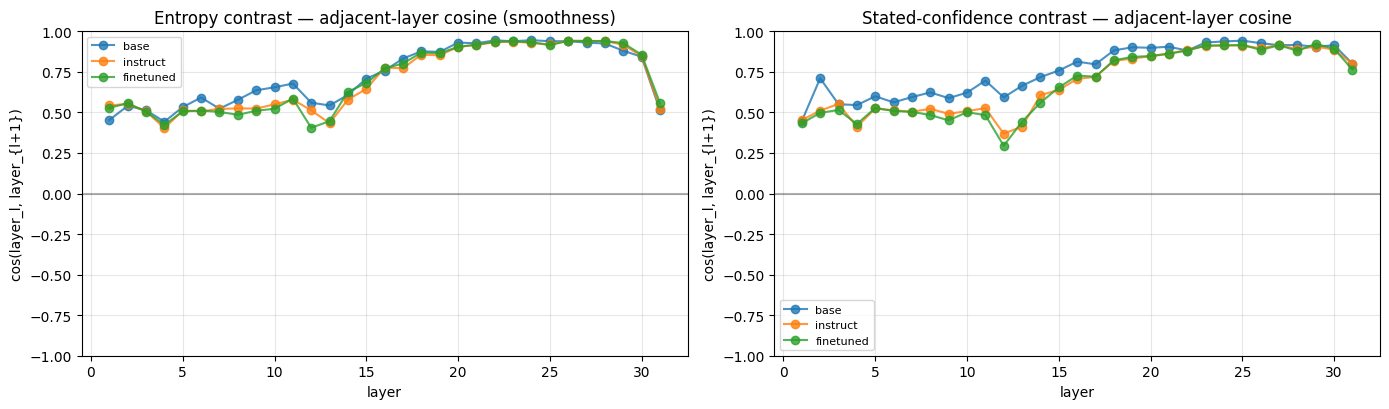


Adjacent-layer cosine smoothness (median across layers):
  [base] entropy_contrast           median=+0.7084  min=+0.4429  argmin=layer 4
  [base] stated_conf_contrast       median=+0.7967  min=+0.4470  argmin=layer 1
  [instruct] entropy_contrast           median=+0.6448  min=+0.4023  argmin=layer 4
  [instruct] stated_conf_contrast       median=+0.7068  min=+0.3689  argmin=layer 12
  [finetuned] entropy_contrast           median=+0.6810  min=+0.4052  argmin=layer 12
  [finetuned] stated_conf_contrast       median=+0.7200  min=+0.2945  argmin=layer 12


In [11]:
# Direction magnitudes (L2 norm) per layer — the directions ARE unit-normalised on save,
# but mean-diff magnitude before normalisation is informative: how big is the *raw* shift in
# activation space between high- and low-tail groups? Stored implicitly via the saved metadata
# thresholds; here we just plot the cosine between adjacent layers as a smoothness diagnostic.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for r in RUNS:
    ec = r.entropy_contrast_dirs()
    sc = r.stated_conf_contrast_dirs()
    if ec:
        arr, layers = _stack_layers(ec)
        smooth = [_cosine(arr[i], arr[i+1]) for i in range(len(layers)-1)]
        axes[0].plot(layers[1:], smooth, 'o-', alpha=0.8, label=r.label)
    if sc:
        arr, layers = _stack_layers(sc)
        smooth = [_cosine(arr[i], arr[i+1]) for i in range(len(layers)-1)]
        axes[1].plot(layers[1:], smooth, 'o-', alpha=0.8, label=r.label)
axes[0].set_title('Entropy contrast — adjacent-layer cosine (smoothness)')
axes[1].set_title('Stated-confidence contrast — adjacent-layer cosine')
for ax in axes:
    ax.set_xlabel('layer'); ax.set_ylabel('cos(layer_l, layer_{l+1})')
    ax.set_ylim(-1, 1); ax.axhline(0, color='black', alpha=0.3); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nAdjacent-layer cosine smoothness (median across layers):")
for r in RUNS:
    for kind, getter in [('entropy_contrast', r.entropy_contrast_dirs),
                          ('stated_conf_contrast', r.stated_conf_contrast_dirs)]:
        d = getter()
        if d is None: continue
        arr, layers = _stack_layers(d)
        smooth = np.array([_cosine(arr[k], arr[k+1]) for k in range(len(layers)-1)])
        print(f"  [{r.label}] {kind:25s}  median={np.median(smooth):+.4f}  "
              f"min={smooth.min():+.4f}  argmin=layer {layers[1+int(np.argmin(smooth))]}")


---
## Section 4 — Movement of contrast directions across model variants

If you've loaded multiple runs (e.g. `base`, `instruct`, `finetuned`), this section visualises how each direction *rotates* between variants per layer. Cosine close to 1 = direction unchanged; close to 0 = direction is now ~orthogonal (different axis); negative = flipped.

If only one run is loaded, this section says so and skips.

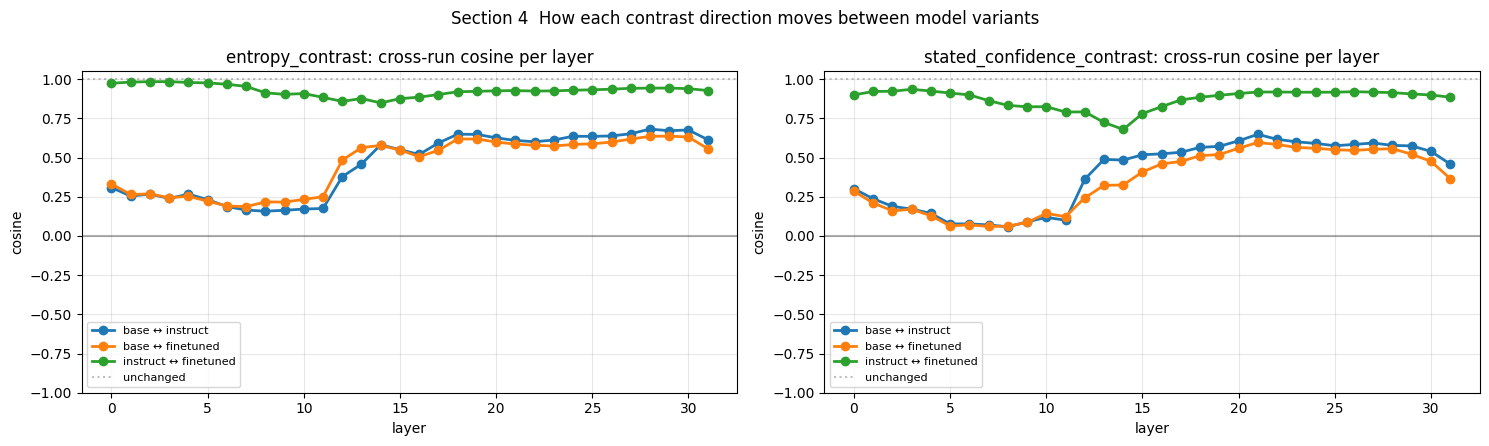


Cross-run cosine summary (mean / median over layers):
  entropy_contrast           base ↔ instruct:  mean=+0.4568  median=+0.5658  range=[+0.1579,+0.6815]
  entropy_contrast           base ↔ finetuned:  mean=+0.4539  median=+0.5527  range=[+0.1867,+0.6370]
  entropy_contrast           instruct ↔ finetuned:  mean=+0.9279  median=+0.9274  range=[+0.8487,+0.9843]
  stated_conf_contrast       base ↔ instruct:  mean=+0.3951  median=+0.5032  range=[+0.0583,+0.6483]
  stated_conf_contrast       base ↔ finetuned:  mean=+0.3519  median=+0.3871  range=[+0.0605,+0.5965]
  stated_conf_contrast       instruct ↔ finetuned:  mean=+0.8730  median=+0.8997  range=[+0.6793,+0.9354]


In [12]:
# Pairwise per-layer cosine between every pair of runs, separately for entropy & stated-conf contrast.

if len(RUNS) < 2:
    print(f"Only {len(RUNS)} run loaded — direction-movement plot needs ≥2. Skipping Section 4.")
else:
    pairs = [(RUNS[i], RUNS[j]) for i in range(len(RUNS)) for j in range(i+1, len(RUNS))]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    for kind, ax, getter in [
        ('entropy_contrast',          axes[0], 'entropy_contrast_dirs'),
        ('stated_confidence_contrast', axes[1], 'stated_conf_contrast_dirs'),
    ]:
        for ra, rb in pairs:
            da = getattr(ra, getter)()
            db = getattr(rb, getter)()
            if da is None or db is None:
                continue
            a_arr, layers = _stack_layers(da)
            b_arr, _ = _stack_layers(db)
            n = min(len(a_arr), len(b_arr))
            cos = np.array([_cosine(a_arr[i], b_arr[i]) for i in range(n)])
            ax.plot(layers[:n], cos, 'o-', linewidth=2, label=f"{ra.label} ↔ {rb.label}")
        ax.axhline(0, color='black', alpha=0.3)
        ax.axhline(1, color='gray', linestyle=':', alpha=0.5, label='unchanged')
        ax.set_xlabel('layer'); ax.set_ylabel('cosine')
        ax.set_title(f'{kind}: cross-run cosine per layer')
        ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(-1, 1.05)
    plt.suptitle('Section 4  How each contrast direction moves between model variants')
    plt.tight_layout(); plt.show()

# ---- text output ----
if len(RUNS) >= 2:
    pairs = [(RUNS[i], RUNS[j]) for i in range(len(RUNS)) for j in range(i+1, len(RUNS))]
    print("\nCross-run cosine summary (mean / median over layers):")
    for kind, getter in [('entropy_contrast', 'entropy_contrast_dirs'),
                          ('stated_conf_contrast', 'stated_conf_contrast_dirs')]:
        for ra, rb in pairs:
            da = getattr(ra, getter)(); db = getattr(rb, getter)()
            if da is None or db is None: continue
            a_arr, layers = _stack_layers(da); b_arr, _ = _stack_layers(db)
            n = min(len(a_arr), len(b_arr))
            cos = np.array([_cosine(a_arr[k], b_arr[k]) for k in range(n)])
            print(f"  {kind:25s}  {ra.label} ↔ {rb.label}:  mean={cos.mean():+.4f}  median={np.median(cos):+.4f}  range=[{cos.min():+.4f},{cos.max():+.4f}]")


/tmp/ipykernel_618834/3448271424.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 0.95, 0.95)); plt.show()


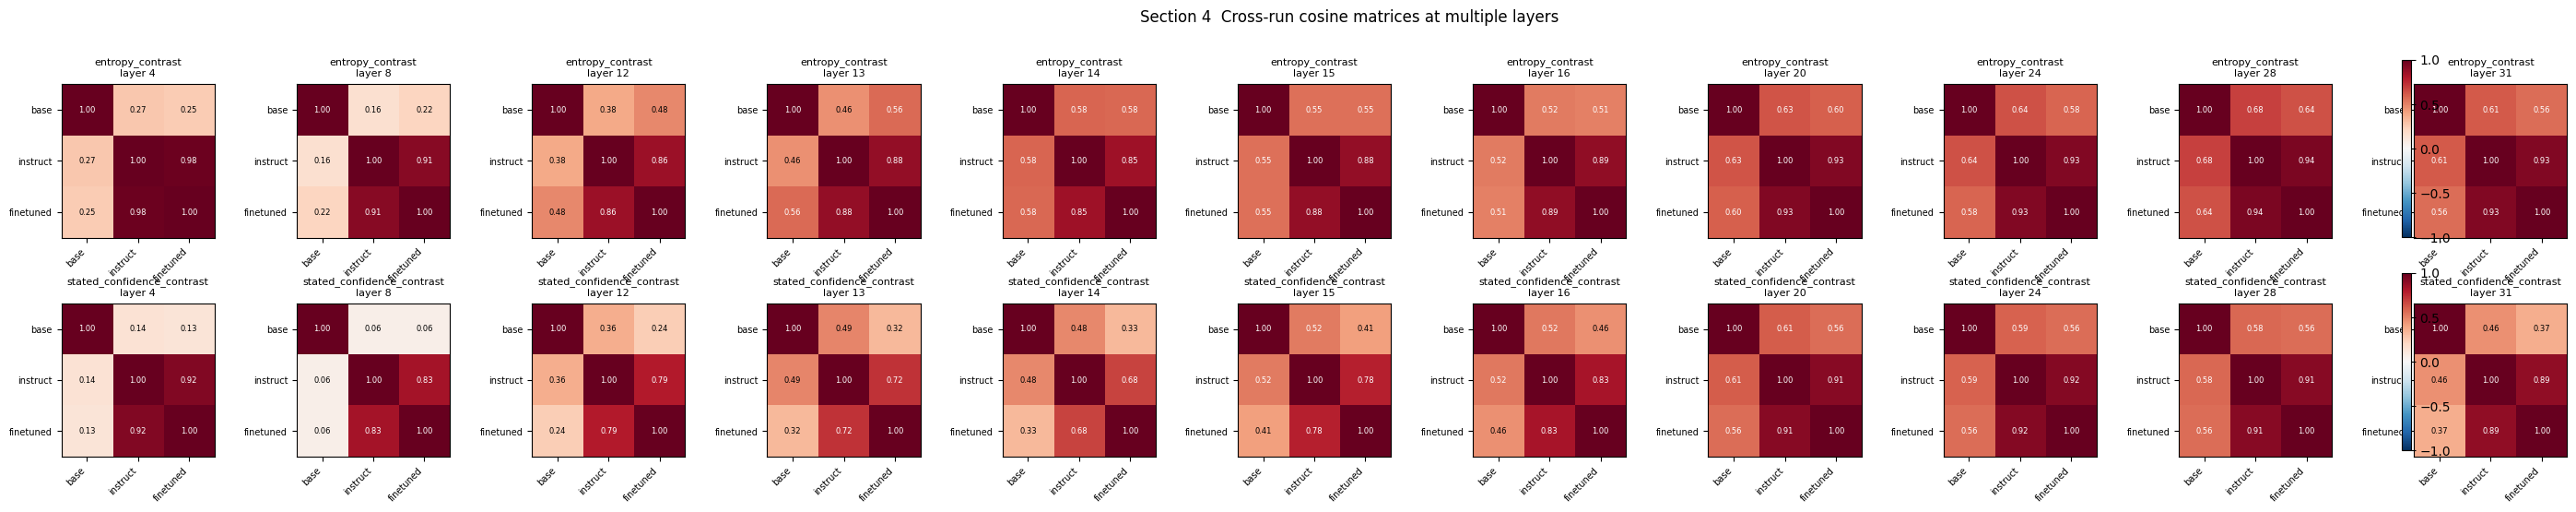


Cross-run cosine matrices @ FOCAL_LAYERS=[4, 8, 12, 13, 14, 15, 16, 20, 24, 28, 31]:
  layer 4 — entropy_contrast:
              base  +1.0000  +0.2669  +0.2531
          instruct  +0.2669  +1.0000  +0.9790
         finetuned  +0.2531  +0.9790  +1.0000
  layer 4 — stated_confidence_contrast:
              base  +1.0000  +0.1442  +0.1289
          instruct  +0.1442  +1.0000  +0.9243
         finetuned  +0.1289  +0.9243  +1.0000
  layer 8 — entropy_contrast:
              base  +1.0000  +0.1579  +0.2171
          instruct  +0.1579  +1.0000  +0.9131
         finetuned  +0.2171  +0.9131  +1.0000
  layer 8 — stated_confidence_contrast:
              base  +1.0000  +0.0583  +0.0621
          instruct  +0.0583  +1.0000  +0.8329
         finetuned  +0.0621  +0.8329  +1.0000
  layer 12 — entropy_contrast:
              base  +1.0000  +0.3780  +0.4835
          instruct  +0.3780  +1.0000  +0.8584
         finetuned  +0.4835  +0.8584  +1.0000
  layer 12 — stated_confidence_contrast:
            

In [13]:
# Cross-run cosine matrices at user-specified layers.
# Pre-pick the layers you care about — the runner has 32 (Llama-3.1-8B), so
# good defaults are early/mid/late representative depths. Edit this list and
# re-run the cell to inspect different layers.
FOCAL_LAYERS = [4, 8, 12, 13, 14, 15, 16, 20, 24, 28, 31]   # any subset of 0..31

if len(RUNS) < 2:
    print('Skipping — only one run.')
else:
    fig, axes = plt.subplots(
        2, len(FOCAL_LAYERS),
        figsize=(2.7 * len(FOCAL_LAYERS), 5.5),
        squeeze=False,
    )
    for kind_idx, (kind, getter) in enumerate([
        ('entropy_contrast',           'entropy_contrast_dirs'),
        ('stated_confidence_contrast', 'stated_conf_contrast_dirs'),
    ]):
        for col, focal_layer in enumerate(FOCAL_LAYERS):
            n = len(RUNS)
            M = np.full((n, n), np.nan)
            for ii, ri in enumerate(RUNS):
                for jj, rj in enumerate(RUNS):
                    di = getattr(ri, getter)(); dj = getattr(rj, getter)()
                    if di is None or dj is None: continue
                    a_arr, lay = _stack_layers(di); b_arr, _ = _stack_layers(dj)
                    if focal_layer not in lay: continue
                    k = lay.index(focal_layer)
                    M[ii, jj] = _cosine(a_arr[k], b_arr[k])
            ax = axes[kind_idx, col]
            im = ax.imshow(M, vmin=-1, vmax=1, cmap='RdBu_r')
            ax.set_xticks(range(n)); ax.set_yticks(range(n))
            ax.set_xticklabels([r.label for r in RUNS], rotation=45, ha='right', fontsize=7)
            ax.set_yticklabels([r.label for r in RUNS], fontsize=7)
            for ii in range(n):
                for jj in range(n):
                    if not np.isnan(M[ii,jj]):
                        ax.text(jj, ii, f'{M[ii,jj]:.2f}', ha='center', va='center', fontsize=6,
                                color='black' if abs(M[ii,jj]) < 0.5 else 'white')
            ax.set_title(f'{kind}\nlayer {focal_layer}', fontsize=8)
        # one shared colorbar at the right of each row
        plt.colorbar(im, ax=axes[kind_idx, :].tolist(), fraction=0.02, pad=0.02)
    plt.suptitle('Section 4  Cross-run cosine matrices at multiple layers')
    plt.tight_layout(rect=(0, 0, 0.95, 0.95)); plt.show()

    # ---- text output ----
    print(f"\nCross-run cosine matrices @ FOCAL_LAYERS={FOCAL_LAYERS}:")
    for focal_layer in FOCAL_LAYERS:
        for kind, getter in [('entropy_contrast',           'entropy_contrast_dirs'),
                             ('stated_confidence_contrast', 'stated_conf_contrast_dirs')]:
            print(f"  layer {focal_layer} — {kind}:")
            for ii, ri in enumerate(RUNS):
                vals = []
                for jj, rj in enumerate(RUNS):
                    di = getattr(ri, getter)(); dj = getattr(rj, getter)()
                    if di is None or dj is None: vals.append('   nan'); continue
                    a_arr, lay = _stack_layers(di); b_arr, _ = _stack_layers(dj)
                    if focal_layer not in lay: vals.append('   nan'); continue
                    k = lay.index(focal_layer)
                    vals.append(f"{_cosine(a_arr[k], b_arr[k]):+8.4f}")
                print(f"    {ri.label[:14]:>14s} " + " ".join(vals))


---
## Section 5 — Logit lens

Reads the per-layer lensed-logit NPZs the runner saved.

### Two lens flavours: vanilla vs tuned

The first cell of this notebook has `LENS_KIND = "vanilla" | "tuned"`. The plots below all read whichever lens you've selected. To compare the two, change `LENS_KIND` and re-run from Section 5 down.

- **Vanilla** = the model's own final RMSNorm + unembedding applied to each layer's residual. Free, no training. Unreliable at early/mid layers because `W_U` was trained against the FINAL residual basis.
- **Tuned** = Belrose et al. 2023. A per-layer affine transform `(A_L, b_L)` is trained so that `W_U @ FinalLN(A_L · resid_L + b_L)` matches the model's actual final-layer logits in KL divergence. Reliable across all layers; the affines were saved to `<prefix>_tuned_lens.pt` during the run.

**The activations being lensed.** For both flavours, the underlying residual stream is taken at the LAST PROMPT TOKEN — the position whose next-token logits ARE the model's answer / confidence digit. The model is not generating; we do one forward pass per prompt and read the residual at position −1.

**Recommendation.** For exploratory analysis vanilla is fine. For paper-ready figures use tuned — workshop reviewers will ask why you didn't.


### Section 5.1  Mean per-option logit trajectory across layers

For every question, the runner saved the unembedded **logit** at each of the 32 layers for each option ('A','B','C','D' for the direct prompt; '1'..'10' for the meta prompt). Here we average each option's logit across all 1713 questions and plot it as a function of layer.

**What "logit" means here.** The y-axis is the value you'd get by projecting that layer's residual stream straight through the model's final RMSNorm + unembedding:

```
lensed_logit_at_layer_L_for_option_X
    = sum-over-sub-tokens-of-X  of  (W_U @ FinalLN(resid_at_layer_L))[token_id]   (logsumexp)
```

Sub-token aggregation matches `finetune.run_evaluations.run_mcq_forward_pass` — for an option like 'A' we sum the probability mass on both `' A'` and `'A'` via `logsumexp`. So each line is the per-layer logit for **the answer-letter token group**.

**An important caveat about absolute values.** Logit magnitudes grow through the network because the residual stream's L2 norm grows. The fact that the curves rise from ~0 at layer 0 to ~25 at the final layer is mostly *that*, not "the model becomes 25× more confident in this option". What's diagnostic in this plot is:

1. **Relative ordering between options at the same layer** — which option's logit is highest at layer L tells you what the model would output if you stopped the forward pass there.
2. **The layer at which curves separate** — early layers have all option logits clustered (no preference); later layers have the chosen option pulling ahead. The separation layer is where the answer-relevant information first becomes legible to the unembedding.

If you want a NORMALISED reading of "how much probability does the model put on this option at layer L", apply softmax across the option-token logits at that layer — but Section 5.2 already does this implicitly (via argmax) so usually the unnormalised plot here is enough.


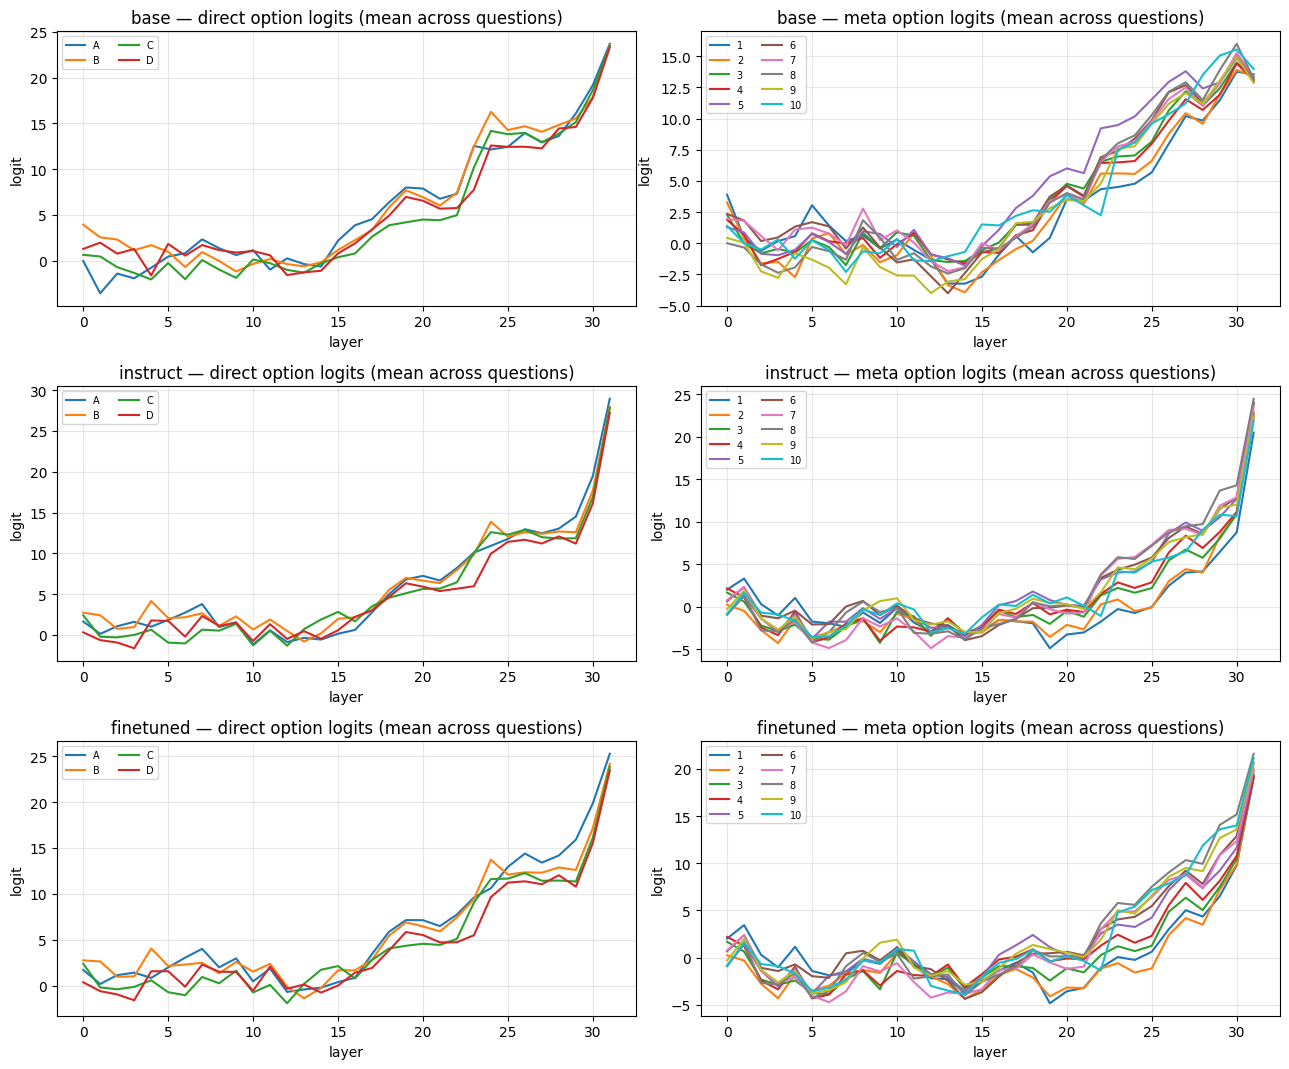


Logit-lens option trajectories — final-layer mean per option:
  [base] direct final-layer mean: A=+23.689  B=+23.490  C=+23.421  D=+23.297
    peak-layer per option: A=L31  B=L31  C=L31  D=L31
  [base] meta   final-layer mean: 1=+13.554  2=+13.391  3=+13.319  4=+13.098  5=+13.323  6=+12.970  7=+13.335  8=+13.196  9=+12.855  10=+13.973
    peak-layer per option: 1=L30  2=L30  3=L30  4=L30  5=L30  6=L30  7=L30  8=L30  9=L30  10=L30
  [instruct] direct final-layer mean: A=+28.933  B=+27.930  C=+27.834  D=+27.223
    peak-layer per option: A=L31  B=L31  C=L31  D=L31
  [instruct] meta   final-layer mean: 1=+20.484  2=+22.919  3=+22.630  4=+22.251  5=+23.863  6=+24.038  7=+23.505  8=+24.454  9=+22.367  10=+21.833
    peak-layer per option: 1=L31  2=L31  3=L31  4=L31  5=L31  6=L31  7=L31  8=L31  9=L31  10=L31
  [finetuned] direct final-layer mean: A=+25.262  B=+24.181  C=+23.820  D=+23.443
    peak-layer per option: A=L31  B=L31  C=L31  D=L31
  [finetuned] meta   final-layer mean: 1=+19.022 

In [14]:
# Section 5.1 — mean trajectory of each option's logit per layer.
fig, axes = plt.subplots(len(RUNS), 2, figsize=(13, 3.6 * len(RUNS)), squeeze=False)

for ri, r in enumerate(RUNS):
    for col, (kind, getter) in enumerate([('direct', r.direct_lens), ('meta', r.meta_lens)]):
        ax = axes[ri, col]
        lens = getter()
        if lens is None:
            ax.text(0.5, 0.5, f'no {kind}_logit_lens.npz', ha='center', va='center'); ax.set_axis_off()
            continue
        opt_logits = lens['option_logits']     # (n_q, n_layers, n_options)
        opt_strs   = [str(s) for s in lens['option_strs']]
        layers     = list(lens['layer_indices'])
        means = opt_logits.mean(axis=0)         # (n_layers, n_options)
        for k, label in enumerate(opt_strs):
            ax.plot(layers, means[:, k], label=str(label), linewidth=1.5)
        ax.set_title(f'{r.label} — {kind} option logits (mean across questions)')
        ax.set_xlabel('layer'); ax.set_ylabel('logit')
        ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---- text output ----
print("\nLogit-lens option trajectories — final-layer mean per option:")
for r in RUNS:
    for kind, getter in [('direct', r.direct_lens), ('meta', r.meta_lens)]:
        lens = getter()
        if lens is None: continue
        opt_logits = lens['option_logits']
        opt_strs = [str(s) for s in lens['option_strs']]
        layers = list(lens['layer_indices'])
        means = opt_logits.mean(axis=0)
        last = means[-1]
        print(f"  [{r.label}] {kind:6s} final-layer mean: " +
              "  ".join(f"{s}={v:+.3f}" for s, v in zip(opt_strs, last)))
        # peak layer per option
        peak = means.argmax(axis=0)
        print(f"    peak-layer per option: " + "  ".join(f"{s}=L{layers[int(p)]}" for s, p in zip(opt_strs, peak)))


### Section 5.1b  Aggregated trajectories — one line per (model, prompt type)

The per-option plot above shows every letter / digit individually for every model. This aggregated view collapses across options, so each model gets exactly **two** lines:

- **Solid line** = direct prompt (averaged across A/B/C/D).
- **Dotted line** = meta prompt (averaged across 1..10).

Both lines for a model share the same colour, so you can compare a model's direct vs meta trajectories at a glance. The aggregation is `option_logits.mean(axis=(0, 2))` — average across both questions and options at each layer.

**What the line represents.** A typical option's lensed logit at layer L. Same caveat as 5.1: absolute values reflect residual-stream norm growth more than "model confidence". The interesting thing here is the **shape** — when does each model's residual stream start carrying answer-token-style information?

**What to look for**:
- **Direct vs meta gap.** If the meta line tracks the direct line in shape (just shifted), the meta prompt isn't doing anything radically different to the residual stream — it's reading off similar features at similar depths.
- **Cross-model gaps.** If finetuned's curves rise earlier than instruct's, the adapter has shifted the layer where answer-relevant features become legible (could be the model "deciding" sooner, or just rebalancing residual norms).
- **Direct above or below meta.** Direct having higher absolute logits than meta is mostly a tokenization artefact (digit tokens vs letter tokens have different prior frequencies in the unembedding) and doesn't mean much by itself.


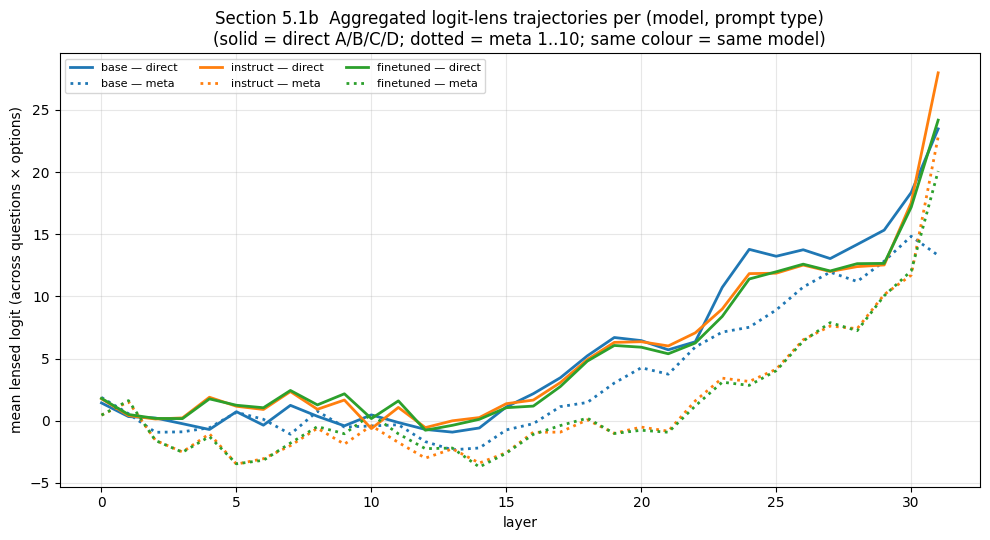


Aggregated logit-lens trajectories per (run, prompt type):
  [base] direct  layer-0=+1.435  layer-16=+2.178  final=+23.474  peak=+23.474@L31
  [base] meta    layer-0=+1.877  layer-16=-0.231  final=+13.301  peak=+14.834@L30
  [instruct] direct  layer-0=+1.772  layer-16=+1.666  final=+27.980  peak=+27.980@L31
  [instruct] meta    layer-0=+0.454  layer-16=-0.922  final=+22.834  peak=+22.834@L31
  [finetuned] direct  layer-0=+1.804  layer-16=+1.180  final=+24.177  peak=+24.177@L31
  [finetuned] meta    layer-0=+0.455  layer-16=-1.091  final=+20.082  peak=+20.082@L31


In [15]:
# Section 5.1b — aggregated logit-lens trajectories per (run, prompt type).
# One solid line for direct (mean across A/B/C/D) and one dotted line for meta
# (mean across 1..10) per model, both in the same colour.
fig, ax = plt.subplots(figsize=(10, 5.5))
_color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for ri, r in enumerate(RUNS):
    color = _color_cycle[ri % len(_color_cycle)]
    for style, kind, getter in [('-', 'direct', r.direct_lens),
                                 (':', 'meta',   r.meta_lens)]:
        lens = getter()
        if lens is None: continue
        # Mean across questions (axis 0) and options (axis 2) → one number per layer.
        means = lens['option_logits'].mean(axis=(0, 2))
        layers = list(lens['layer_indices'])
        ax.plot(layers, means, style, color=color, linewidth=2,
                label=f'{r.label} — {kind}')

ax.set_xlabel('layer')
ax.set_ylabel('mean lensed logit (across questions × options)')
ax.set_title('Section 5.1b  Aggregated logit-lens trajectories per (model, prompt type)\n'
             '(solid = direct A/B/C/D; dotted = meta 1..10; same colour = same model)')
ax.legend(fontsize=8, ncol=max(1, len(RUNS))); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nAggregated logit-lens trajectories per (run, prompt type):")
for r in RUNS:
    for kind, getter in [('direct', r.direct_lens), ('meta', r.meta_lens)]:
        lens = getter()
        if lens is None: continue
        means = lens['option_logits'].mean(axis=(0, 2))
        layers = list(lens['layer_indices'])
        peak_l = layers[int(np.argmax(means))]
        print(f"  [{r.label}] {kind:6s}  layer-0={means[0]:+.3f}  "
              f"layer-{layers[len(layers)//2]}={means[len(means)//2]:+.3f}  "
              f"final={means[-1]:+.3f}  peak={means.max():+.3f}@L{peak_l}")


### Section 5.1c  Per-option PROBABILITY trajectory (softmax over the option set)

Same data as Section 5.1, but with a softmax applied across the option-token logits at each layer. The y-axis is now `P(option | option-set) ∈ [0,1]` and is interpretable as **"if you stopped the forward pass at layer L and forced the model to pick from {A,B,C,D} (or {1..10}), what's the probability mass on each option?"**.

Reading: at layer 0 every option is roughly uniform (~25% direct, ~10% meta = 1/N). As layers progress, the chosen option's curve climbs above the others. The layer where one curve clearly pulls away from the rest is when the option-set softmax becomes confident.

This is more directly interpretable than 5.1's raw-logit plot — but mathematically it's a lossy compression (you lose absolute logit magnitudes). Use 5.1 to ask "when does separation emerge?" and 5.1c to ask "what's the model's effective probability on each option at layer L?".


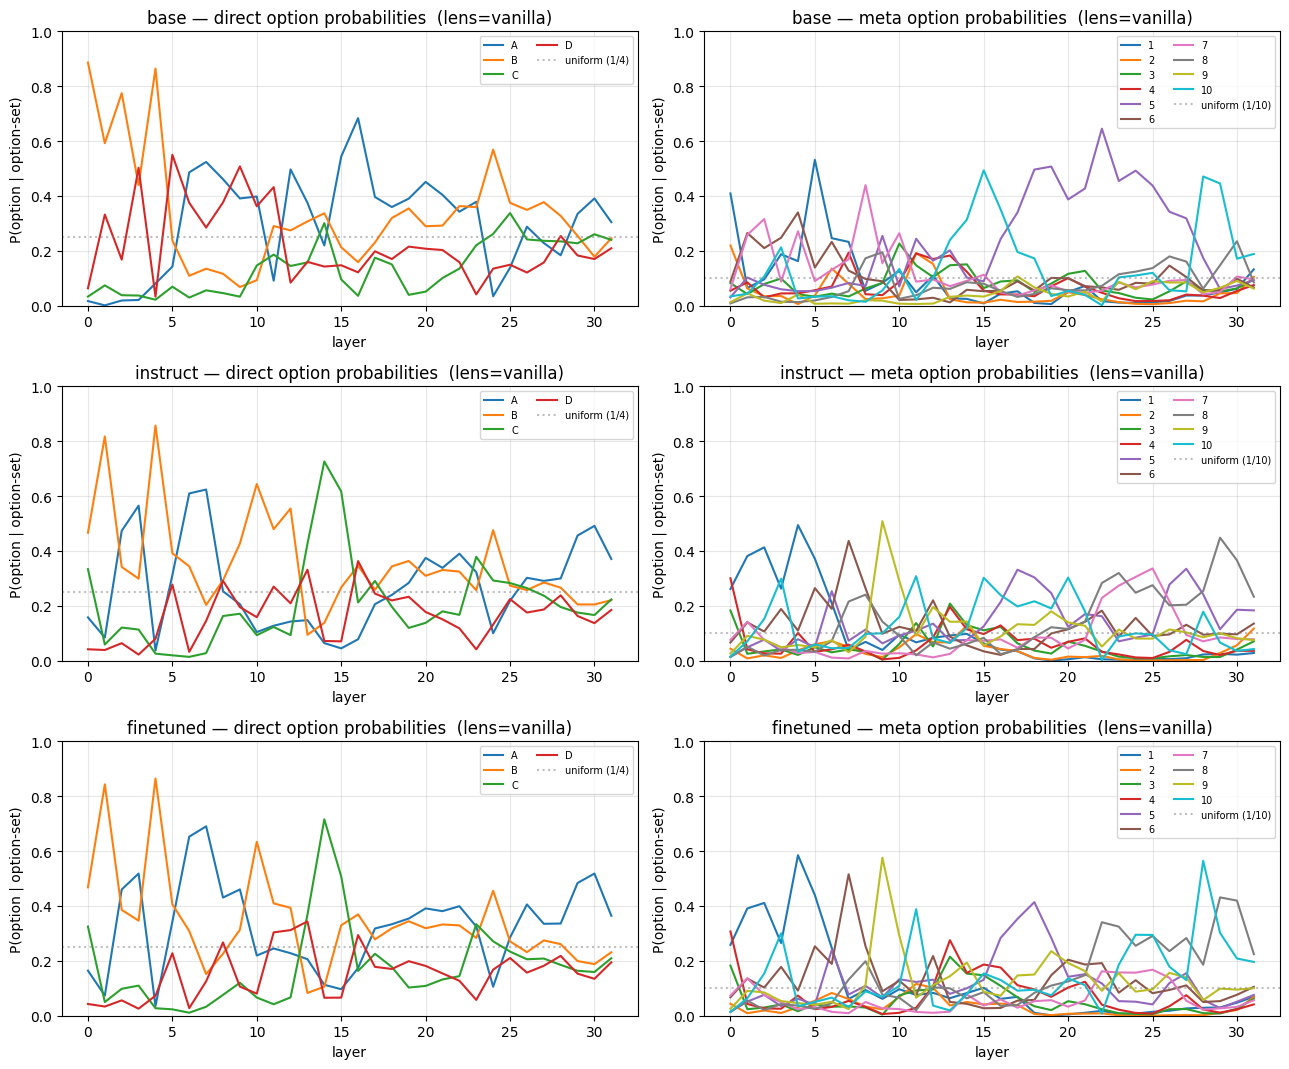


Final-layer softmax-over-options means  (lens=vanilla):
  [base] direct: P(A)=0.305  P(B)=0.246  P(C)=0.240  P(D)=0.209
  [base] meta  : P(1)=0.133  P(2)=0.105  P(3)=0.095  P(4)=0.075  P(5)=0.093  P(6)=0.066  P(7)=0.096  P(8)=0.085  P(9)=0.062  P(10)=0.189
  [instruct] direct: P(A)=0.371  P(B)=0.221  P(C)=0.223  P(D)=0.185
  [instruct] meta  : P(1)=0.028  P(2)=0.117  P(3)=0.071  P(4)=0.036  P(5)=0.183  P(6)=0.135  P(7)=0.078  P(8)=0.233  P(9)=0.075  P(10)=0.042
  [finetuned] direct: P(A)=0.364  P(B)=0.231  P(C)=0.210  P(D)=0.195
  [finetuned] meta  : P(1)=0.069  P(2)=0.069  P(3)=0.062  P(4)=0.041  P(5)=0.076  P(6)=0.105  P(7)=0.056  P(8)=0.225  P(9)=0.101  P(10)=0.196


In [16]:
# Section 5.1c — softmax-over-option-set probabilities, faceted by run × prompt.
fig, axes = plt.subplots(len(RUNS), 2, figsize=(13, 3.6 * len(RUNS)), squeeze=False)

for ri, r in enumerate(RUNS):
    for col, (kind, getter) in enumerate([('direct', r.direct_lens), ('meta', r.meta_lens)]):
        ax = axes[ri, col]
        lens = getter()
        if lens is None:
            ax.text(0.5, 0.5, f'no {kind} lens NPZ for kind={LENS_KIND!r}',
                    ha='center', va='center'); ax.set_axis_off()
            continue
        opt_logits = lens['option_logits']    # (n_q, n_layers, n_options)
        opt_strs = [str(s) for s in lens['option_strs']]
        layers = list(lens['layer_indices'])
        # Per-question softmax over options at each layer; then mean across questions.
        # Use scipy/np softmax to avoid pulling in torch in the plotting cell.
        m = opt_logits - opt_logits.max(axis=2, keepdims=True)
        opt_probs = np.exp(m); opt_probs /= opt_probs.sum(axis=2, keepdims=True)
        means = opt_probs.mean(axis=0)        # (n_layers, n_options)
        for k, label in enumerate(opt_strs):
            ax.plot(layers, means[:, k], label=str(label), linewidth=1.5)
        ax.axhline(1.0 / len(opt_strs), color='gray', linestyle=':', alpha=0.5,
                   label=f'uniform (1/{len(opt_strs)})')
        ax.set_title(f'{r.label} — {kind} option probabilities  (lens={LENS_KIND})')
        ax.set_xlabel('layer'); ax.set_ylabel('P(option | option-set)')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---- text output ----
print(f"\nFinal-layer softmax-over-options means  (lens={LENS_KIND}):")
for r in RUNS:
    for kind, getter in [('direct', r.direct_lens), ('meta', r.meta_lens)]:
        lens = getter()
        if lens is None: continue
        opt_logits = lens['option_logits']
        opt_strs = [str(s) for s in lens['option_strs']]
        m = opt_logits - opt_logits.max(axis=2, keepdims=True)
        p = np.exp(m); p /= p.sum(axis=2, keepdims=True)
        last = p.mean(axis=0)[-1]
        print(f"  [{r.label}] {kind:6s}: " +
              "  ".join(f"P({s})={v:.3f}" for s, v in zip(opt_strs, last)))


### Section 5.1d  Chosen-answer logit trajectory (the option the model actually picked)

§5.1b averaged across **all four options** (and all ten meta digits) — so a question where the model emitted A contributed A's logit *and* B's *and* C's *and* D's equally to each layer's mean. Three quarters of that average is **non-chosen-answer** logit, which dilutes the trajectory.

This plot fixes that. For each question, look up the model's final-layer argmax — the answer it actually emitted — and trace **that specific option's logit** across all 32 layers. Average across questions.

- **Solid line** = direct prompt: chosen-letter logit (A or B or C or D, whichever the model emitted on that question)
- **Dotted line** = meta prompt: chosen-digit logit (1..10, whichever digit the model emitted)
- Same colour = same model.

**Reading this plot vs §5.1b**:

- The **gap** between this plot's chosen-logit trajectory and §5.1b's mean-across-all-options trajectory IS the per-layer "margin" between the chosen option and a typical alternative. A bigger gap = more decisive separation.
- If the chosen-logit curve here rises *earlier* than §5.1b's curve, the model is concentrating mass on its chosen option from early layers (consistent with §5.2's early-commit spike). If they rise together, the chosen option only pulls ahead in the late layers.
- For models with strong A-bias (instruct), this plot's direct curve will sit substantially above §5.1b's direct curve — because the chosen option (often A) consistently has the highest logit while §5.1b averages in three losers.


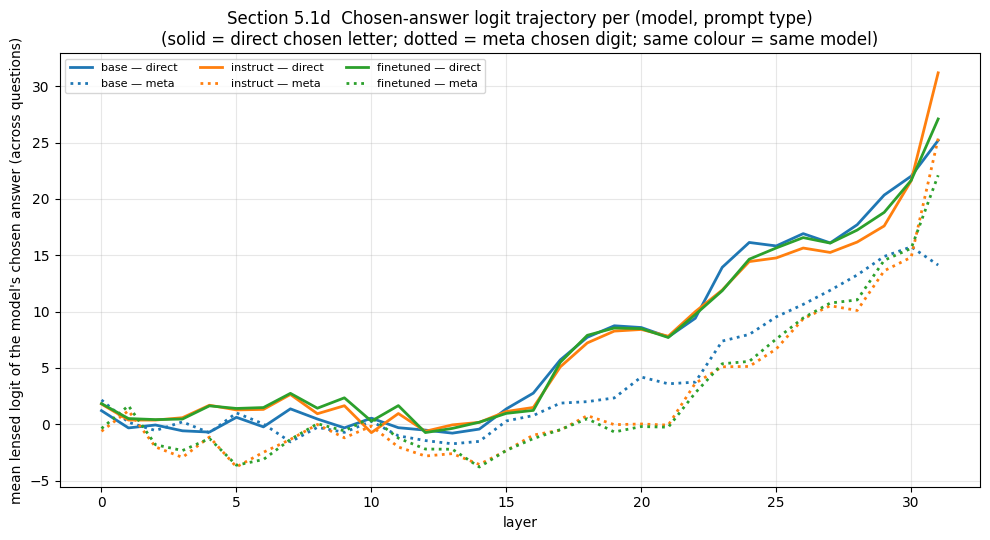


Chosen-answer logit trajectory  (lens=vanilla):
  [base] direct  layer-0=+1.202  layer-16=+2.758  final=+25.192  peak=+25.192@L31
  [base] meta    layer-0=+2.151  layer-16=+0.769  final=+14.125  peak=+15.744@L30
  [instruct] direct  layer-0=+1.788  layer-16=+1.486  final=+31.189  peak=+31.189@L31
  [instruct] meta    layer-0=-0.629  layer-16=-0.965  final=+25.347  peak=+25.347@L31
  [finetuned] direct  layer-0=+1.827  layer-16=+1.225  final=+27.094  peak=+27.094@L31
  [finetuned] meta    layer-0=-0.385  layer-16=-1.274  final=+22.095  peak=+22.095@L31


In [17]:
# Section 5.1d — chosen-answer logit trajectory.
# For each question, find the model's final-layer argmax (the emitted option),
# then track THAT option's logit across all 32 layers. Average across questions.
fig, ax = plt.subplots(figsize=(10, 5.5))
_color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for ri, r in enumerate(RUNS):
    color = _color_cycle[ri % len(_color_cycle)]
    for style, kind, getter in [('-', 'direct', r.direct_lens),
                                 (':', 'meta',   r.meta_lens)]:
        lens = getter()
        if lens is None:
            continue
        opt_logits = lens['option_logits']  # (n_q, n_layers, n_options)
        layers = list(lens['layer_indices'])
        n_q, n_layers, _ = opt_logits.shape

        # Per-question chosen option = argmax at the final layer.
        final_choice = opt_logits[:, -1, :].argmax(axis=1)  # (n_q,)

        # Pull out the chosen option's logit at every layer.
        # shape (n_q, n_layers): chosen_logits[i, l] = opt_logits[i, l, final_choice[i]]
        chosen_logits = opt_logits[
            np.arange(n_q)[:, None],
            np.arange(n_layers)[None, :],
            final_choice[:, None],
        ]
        mean_per_layer = chosen_logits.mean(axis=0)
        ax.plot(layers, mean_per_layer, style, color=color, linewidth=2,
                label=f'{r.label} — {kind}')

ax.set_xlabel('layer')
ax.set_ylabel('mean lensed logit of the model\'s chosen answer (across questions)')
ax.set_title('Section 5.1d  Chosen-answer logit trajectory per (model, prompt type)\n'
             '(solid = direct chosen letter; dotted = meta chosen digit; same colour = same model)')
ax.legend(fontsize=8, ncol=max(1, len(RUNS))); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- text output ----
print(f"\nChosen-answer logit trajectory  (lens={LENS_KIND}):")
for r in RUNS:
    for kind, getter in [('direct', r.direct_lens), ('meta', r.meta_lens)]:
        lens = getter()
        if lens is None: continue
        opt_logits = lens['option_logits']
        n_q, n_layers, _ = opt_logits.shape
        layers = list(lens['layer_indices'])
        final_choice = opt_logits[:, -1, :].argmax(axis=1)
        chosen_logits = opt_logits[
            np.arange(n_q)[:, None],
            np.arange(n_layers)[None, :],
            final_choice[:, None],
        ]
        mean_per_layer = chosen_logits.mean(axis=0)
        peak_l = layers[int(np.argmax(mean_per_layer))]
        print(f"  [{r.label}] {kind:6s}  layer-0={mean_per_layer[0]:+.3f}  "
              f"layer-{layers[len(layers)//2]}={mean_per_layer[len(layers)//2]:+.3f}  "
              f"final={mean_per_layer[-1]:+.3f}  peak={mean_per_layer.max():+.3f}@L{peak_l}")


### Section 5.2  At which layer does each model commit to its choice?

For every question, walk through the 32 layers of the lens and find the **first** layer at which the per-layer lensed argmax matches the **final** layer's argmax (the model's actual output choice). Histogram those "commit layers" across all 1713 questions, one distribution per run.

Two panels:

- **Left — DIRECT lens** (4 options, A/B/C/D). When does the model commit to its answer LETTER?
- **Right — META lens** (10 options, 1..10). When does the model commit to its confidence DIGIT?

**Reading**:
- A **sharp early peak** (e.g. layer 2-3) means the model commits to its choice almost immediately and deeper layers only refine it. The chat-templated instruct model often shows this on the direct lens — it's been trained to make MC decisions in the first answer position.
- A **broad late distribution** means the model deliberates longer.
- A **bimodal distribution** suggests two distinct mechanisms — for example, easy questions decided early and hard questions decided much later. The finetuned model often shows this — early commitment for confident questions, deeper commitment for uncertain ones.

**Comparison between the two panels** is informative: if the meta-lens commit layer is **systematically later** than the direct-lens commit layer for the same model, the model finishes deciding the *answer* first and then computes its confidence on top of that. If commit layers are **simultaneous**, the answer and confidence are being computed in parallel. If meta is *earlier*, the meta prompt is committing to a confidence digit before the model has even fully decided what the answer is — a sign the meta prompt's confidence is decoupled from the actual answer reasoning.


### Aside — why §5.2 and §5.1b look so different

The two plots read the **same per-layer logit grid** but extract different summaries, so a "smoothly rising" §5.1b can coexist with a "sharp early spike" in §5.2.

**§5.1b** (the rising line plot ~0 → ~25):

```
mean over all questions, all options, of the lensed logit at layer L
```
Per layer, one scalar = the *typical magnitude* of an option logit. Averaging across A/B/C/D washes out which option is winning — it answers **"how big are the logits as a whole at layer L?"**

**§5.2** (this histogram):

```
for each question, the FIRST layer at which argmax over A/B/C/D == final-layer argmax
```
Per question, one integer = the layer at which the model's eventual answer first beats the other three. Sensitive only to the *ordering* of the four logits, completely insensitive to magnitude.

#### Why they decouple

- **§5.1b answers "how loud is the projection?"** — driven mostly by the residual stream's L2 norm growing through the network (a generic property of transformer depth). Letter tokens vs digit tokens differ in unembedding-row norms, which is why direct trajectories sit ~10 logit units above meta. None of this depends on which option is on top.
- **§5.2 answers "when does the winner stabilise?"** — driven by the *gap* between the top option and the rest, not the absolute scale.

#### Concrete example

Imagine the lens at one question gives `[logit_A, logit_B, logit_C, logit_D]` at each layer:

| Layer | logits | §5.1b contribution (mean) | §5.2 contribution (argmax) |
|---|---|---|---|
| 0 | `[1.0, 0.5, 0.5, 0.5]` | 0.625 | A ✓ → first-match goes in **L0 bin**; this question never contributes again |
| 5 | `[2.5, 2.0, 2.0, 2.0]` | 2.125 | A |
| 15 | `[8.0, 7.0, 7.0, 7.0]` | 7.25 | A |
| 31 | `[25.0, 22.0, 22.0, 22.0]` | 22.75 | A (final answer) |

§5.1b plots `0.625 → 2.125 → 7.25 → 22.75` — a smooth slow rise. §5.2 records "first match at L0" regardless of the magnitudes after.

#### What this means in practice

Both can be true simultaneously: the *ranking* of options is set early (§5.2), but the *margins* keep growing through the network (§5.1b). The "decisions early, margins grow late" pattern is consistent with what we know about chat-tuned LLMs — instruction tuning bakes A-biases and answer-letter habits into early layers, and later layers boost the chosen option's logit higher and higher (squashing alternatives into the floor). The §5.2 caveat about vanilla-lens early-layer artefacts still applies, but even after a tuned-lens correction §5.1b will still rise smoothly while §5.2 retains an early spike. They're complementary views of the same per-layer logit grid.


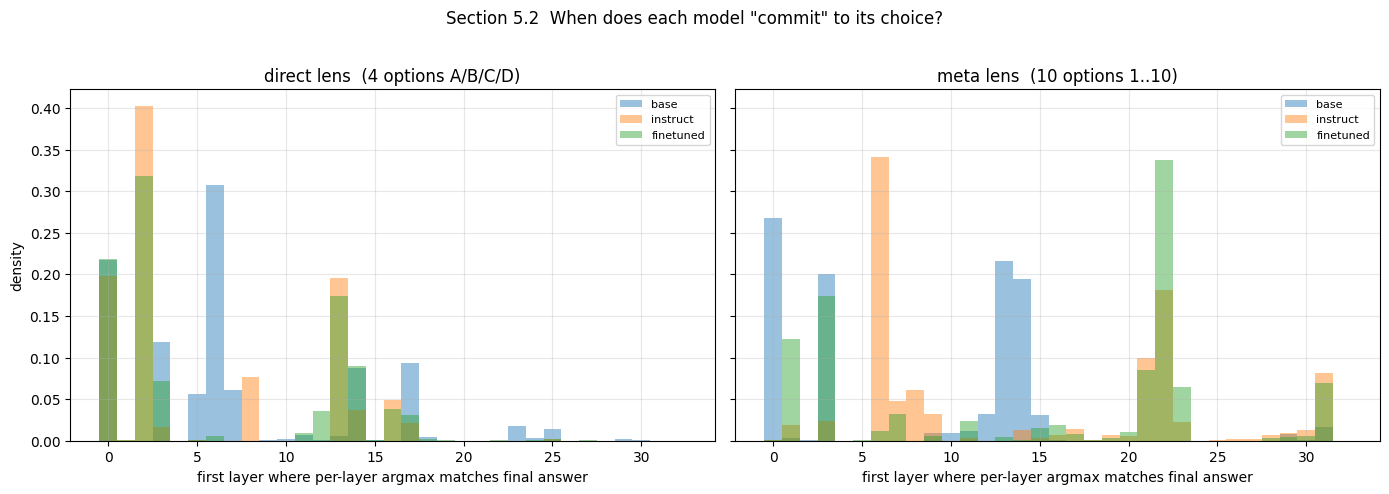


First-layer-match (lens argmax = final answer) — distribution per run / prompt type:
  [direct lens]
    base                       median=6  p25=3  p75=7  mean=6.89  (max=32)
    instruct                   median=2  p25=2  p75=13  mean=5.72  (max=32)
    finetuned                  median=2  p25=2  p75=13  mean=6.25  (max=32)
  [meta lens]
    base                       median=11  p25=0  p75=13  mean=8.03  (max=32)
    instruct                   median=9  p25=6  p75=22  mean=14.25  (max=32)
    finetuned                  median=21  p25=3  p75=22  mean=15.47  (max=32)


In [18]:
# Section 5.2 — at what layer does the per-layer lensed argmax first match the final-layer argmax?
# One panel per prompt type:
#   left  = DIRECT lens (4 options A/B/C/D — "when does the model commit to a letter?")
#   right = META  lens (10 options 1..10  — "when does the model commit to a confidence digit?")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, kind, getter in [(axes[0], 'direct', lambda r: r.direct_lens()),
                         (axes[1], 'meta',   lambda r: r.meta_lens())]:
    for r in RUNS:
        lens = getter(r)
        if lens is None:
            continue
        opt_logits = lens['option_logits']    # (n_q, L, n_options)
        layers = list(lens['layer_indices'])
        final_choice = opt_logits[:, -1, :].argmax(axis=1)
        per_layer_argmax = opt_logits.argmax(axis=2)
        n_q, L = per_layer_argmax.shape
        first_match = np.full(n_q, L)
        for li in range(L):
            not_yet = first_match == L
            match_now = per_layer_argmax[:, li] == final_choice
            first_match[not_yet & match_now] = li
        ax.hist(first_match, bins=np.arange(0, L + 2) - 0.5,
                alpha=0.45, density=True, label=r.label)
    n_options_label = '4 options A/B/C/D' if kind == 'direct' else '10 options 1..10'
    ax.set_xlabel('first layer where per-layer argmax matches final answer')
    ax.set_title(f'{kind} lens  ({n_options_label})')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('density')
plt.suptitle('Section 5.2  When does each model "commit" to its choice?', y=1.02)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nFirst-layer-match (lens argmax = final answer) — distribution per run / prompt type:")
for kind, getter in [('direct', lambda r: r.direct_lens()),
                     ('meta',   lambda r: r.meta_lens())]:
    print(f"  [{kind} lens]")
    for r in RUNS:
        lens = getter(r)
        if lens is None: continue
        opt_logits = lens['option_logits']
        L = opt_logits.shape[1]
        final_choice = opt_logits[:, -1, :].argmax(axis=1)
        per_layer_argmax = opt_logits.argmax(axis=2)
        n_q = per_layer_argmax.shape[0]
        first_match = np.full(n_q, L)
        for li in range(L):
            not_yet = first_match == L
            first_match[not_yet & (per_layer_argmax[:, li] == final_choice)] = li
        print(f"    {r.label:25s}  median={int(np.median(first_match))}  "
              f"p25={int(np.percentile(first_match, 25))}  p75={int(np.percentile(first_match, 75))}  "
              f"mean={first_match.mean():.2f}  (max={L})")


### Section 5.3  Final-layer top-1 token

At the LAST layer of the lens — i.e. the model's actual unembedding — what's the most-likely token across questions? Bar chart of token-id frequencies (decoded to readable strings if a tokenizer is loadable).

**Reading**:
- For the **direct** prompt, the dominant tokens should be the answer-letter set (`' A'`, `' B'`, `' C'`, `' D'` and possibly their no-space variants). If something else dominates (e.g. `'the'`, `'\n'`), the model is escaping the MC framing or your prompt template is broken.
- For the **meta** prompt, dominant tokens should be the digit set (`' 1'`..`' 10'` for the numeric scale). Same story — anything else dominating means a template / scale issue.

This is mostly a sanity check that the prompt pipeline ends in the model emitting the right *kind* of token. Big anomalies here invalidate downstream §6 probe interpretations.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


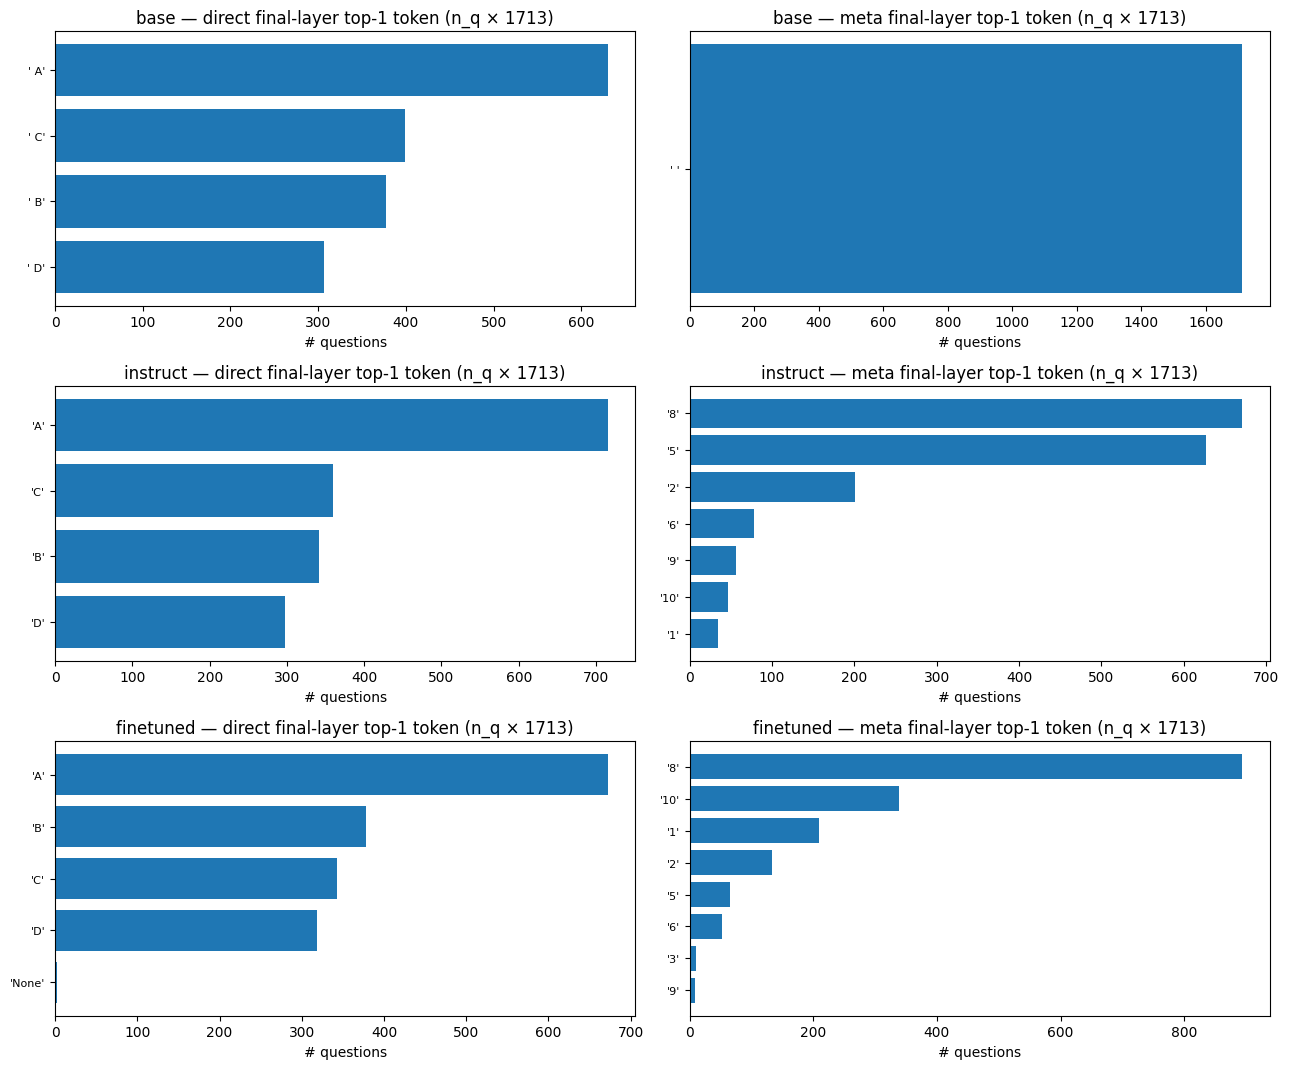


Final-layer top-1 token distribution (top 10 per run/prompt):
  [base] direct top-10: ' A'=630  ' C'=399  ' B'=377  ' D'=307
  [base] meta   top-10: ' '=1713
  [instruct] direct top-10: 'A'=715  'C'=359  'B'=341  'D'=298
  [instruct] meta   top-10: '8'=671  '5'=627  '2'=201  '6'=78  '9'=56  '10'=46  '1'=34
  [finetuned] direct top-10: 'A'=672  'B'=378  'C'=343  'D'=318  'None'=2
  [finetuned] meta   top-10: '8'=894  '10'=339  '1'=209  '2'=133  '5'=66  '6'=53  '3'=10  '9'=9


In [19]:
# Section 5.3 — top-1 vocab token at the final layer per question; show the most common ones (decoded if possible).

# Try to decode token IDs using the tokenizer for the first run's base model.
# Decoding requires HF transformers + network/cache; if unavailable, fall back to raw IDs.
try:
    from transformers import AutoTokenizer
    _tok_cache = {}
    def _tokenizer(model_name):
        if model_name not in _tok_cache:
            _tok_cache[model_name] = AutoTokenizer.from_pretrained(model_name)
        return _tok_cache[model_name]
    _have_tok = True
except Exception as e:
    print(f"(skipping decoding — transformers/tokenizer unavailable: {e})")
    _have_tok = False

from collections import Counter
fig, axes = plt.subplots(len(RUNS), 2, figsize=(13, 3.6 * len(RUNS)), squeeze=False)

for ri, r in enumerate(RUNS):
    base = r.config.get('base_model_name')
    tok = _tokenizer(base) if _have_tok else None
    for col, (kind, getter) in enumerate([('direct', r.direct_lens), ('meta', r.meta_lens)]):
        ax = axes[ri, col]
        lens = getter()
        if lens is None:
            ax.set_axis_off(); continue
        top_ids = lens['top_k_ids']   # (n_q, L, 20)
        # Final-layer top-1 across questions
        top1 = top_ids[:, -1, 0]
        counts = Counter(int(x) for x in top1)
        top10 = counts.most_common(15)
        labels = []
        for tid, _ in top10:
            if tok is not None:
                try: s = repr(tok.decode([tid]))
                except Exception: s = str(tid)
            else:
                s = str(tid)
            labels.append(s)
        vals = [c for _, c in top10]
        ax.barh(range(len(vals))[::-1], vals)
        ax.set_yticks(range(len(vals))[::-1]); ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f'{r.label} — {kind} final-layer top-1 token (n_q × {len(top1)})')
        ax.set_xlabel('# questions')
plt.tight_layout(); plt.show()

# ---- text output ----
from collections import Counter as _Counter
print("\nFinal-layer top-1 token distribution (top 10 per run/prompt):")
for r in RUNS:
    base = r.config.get('base_model_name')
    tok = _tokenizer(base) if _have_tok else None
    for kind, getter in [('direct', r.direct_lens), ('meta', r.meta_lens)]:
        lens = getter()
        if lens is None: continue
        top1 = lens['top_k_ids'][:, -1, 0]
        counts = _Counter(int(x) for x in top1).most_common(10)
        decoded = []
        for tid, c in counts:
            s = repr(tok.decode([tid])) if tok else str(tid)
            decoded.append(f"{s}={c}")
        print(f"  [{r.label}] {kind:6s} top-10: " + "  ".join(decoded))


---
## Section 6 — Linear probes

The runner trained **two probes per layer** during `run_collect_activations.py`, and stored their per-layer R² / accuracy in `*_<metric>_results.json`:

- **Entropy probe (Ridge regression)** — fit on direct activations to predict the question's MC entropy.
  - `direct_to_direct.test_r2` — held-out R² on the direct task (sanity).
  - `direct_to_meta_fixed.r2` — apply the *same* probe to META (confidence-prompt) activations, with separate scaling. This is the "introspection transfer" test: if the model uses the same uncertainty axis when verbalising confidence, this stays high.
  - `direct_to_meta_centered.r2` — same but with centered scaling (mean-shift correction, shared variance — the rigorous version).
  - `meta_to_meta.test_r2` — train+test on META directly. Upper bound for how much entropy signal even *exists* in the meta activations.
  - `shuffled_baseline.r2` — train on shuffled-y direct → shuffled R² floor.
- **MC-answer probe (LogisticRegression, 4-class)** — predicts which of A/B/C/D the model picked, from direct activations.
  - `d2d_accuracy` / `d2m_accuracy` per layer.

### Section 6.1  Entropy probe — direct→direct R²

Train a **Ridge regression** probe on direct-task activations to predict the model's MC entropy on the same task. Plot held-out R² per layer, alongside a shuffled-y baseline.

**Reading**:
- **D→D R² rising with layer**: the entropy signal is encoded later in the network. Typical Llama pattern: ~0 at layer 0, peaks around layer 12-20, plateaus or falls slightly toward the final layer.
- **Plateau or fall after some layer**: the signal stops getting more linearly readable after that point. The "best" layer for downstream probing is wherever this peaks.
- **Shuffled baseline ≈ 0**: sanity check. With shuffled-y training labels the probe can't predict (correlation is destroyed). If the shuffled curve is nonzero, you have a leak somewhere.

The peak layer here is the one to use as the *anchor* for steering / intervention experiments. It's also the natural reference point for the §6.2 transfer plot — if the meta-prompt R² drops sharply between this peak layer and the layer where transfer peaks, the model is using a different layer to "read off" entropy when it's about to verbalise confidence.


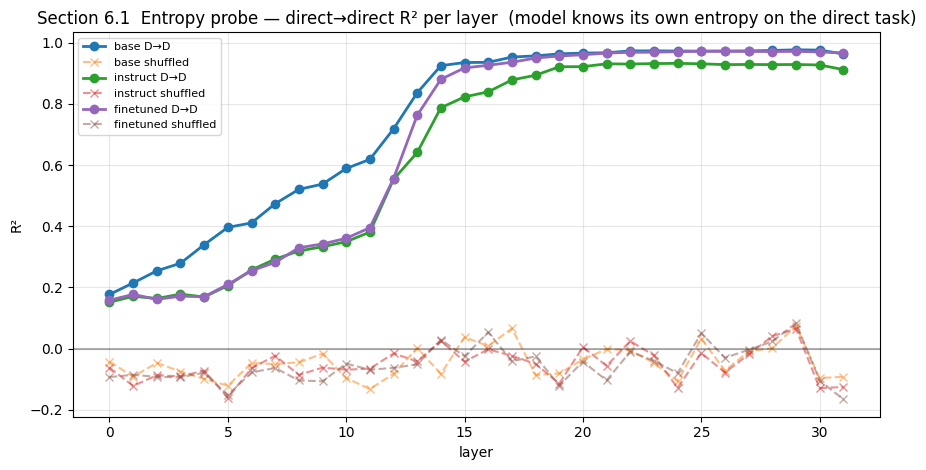


Entropy probe — direct→direct R² (per layer / per run):
  [base]  best D→D R²=0.9771 at layer 29  shuffled-baseline median=-0.0472
    layers:  L0=0.177  L1=0.215  L2=0.254  L3=0.279  L4=0.340  L5=0.396  L6=0.411  L7=0.474  L8=0.521  L9=0.538  L10=0.589  L11=0.619  L12=0.718  L13=0.837  L14=0.925  L15=0.936  L16=0.936  L17=0.953  L18=0.957  L19=0.964  L20=0.966  L21=0.968  L22=0.974  L23=0.974  L24=0.973  L25=0.973  L26=0.973  L27=0.974  L28=0.975  L29=0.977  L30=0.976  L31=0.964
  [instruct]  best D→D R²=0.9329 at layer 24  shuffled-baseline median=-0.0596
    layers:  L0=0.151  L1=0.171  L2=0.164  L3=0.178  L4=0.169  L5=0.206  L6=0.257  L7=0.293  L8=0.319  L9=0.333  L10=0.349  L11=0.381  L12=0.553  L13=0.641  L14=0.788  L15=0.823  L16=0.840  L17=0.879  L18=0.894  L19=0.922  L20=0.922  L21=0.931  L22=0.931  L23=0.932  L24=0.933  L25=0.931  L26=0.929  L27=0.929  L28=0.929  L29=0.929  L30=0.928  L31=0.912
  [finetuned]  best D→D R²=0.9725 at layer 25  shuffled-baseline median=-0.0634
 

In [20]:
# Plot 1: per-layer R² for the ENTROPY probe — direct→direct (probe quality), shuffled (floor).
fig, ax = plt.subplots(figsize=(9, 4.8))
for r in RUNS:
    if not r.results: continue
    pr = r.results.get('probe_results') or {}
    layers = sorted(int(k) for k in pr)
    d2d = [pr[str(l)]['direct_to_direct']['test_r2'] for l in layers]
    shuf = [pr[str(l)]['shuffled_baseline']['r2']   for l in layers]
    ax.plot(layers, d2d, 'o-', linewidth=2, label=f'{r.label} D→D')
    ax.plot(layers, shuf, 'x--', alpha=0.5, label=f'{r.label} shuffled')
ax.axhline(0, color='black', alpha=0.3)
ax.set_xlabel('layer'); ax.set_ylabel('R²')
ax.set_title('Section 6.1  Entropy probe — direct→direct R² per layer  (model knows its own entropy on the direct task)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nEntropy probe — direct→direct R² (per layer / per run):")
for r in RUNS:
    if not r.results: print(f"  [{r.label}] no results.json"); continue
    pr = r.results.get('probe_results') or {}
    layers = sorted(int(k) for k in pr)
    d2d = [pr[str(l)]['direct_to_direct']['test_r2'] for l in layers]
    shuf = [pr[str(l)]['shuffled_baseline']['r2']   for l in layers]
    peak_l = layers[int(np.argmax(d2d))]
    print(f"  [{r.label}]  best D→D R²={max(d2d):.4f} at layer {peak_l}  "
          f"shuffled-baseline median={np.median(shuf):.4f}")
    print(f"    layers:  " + "  ".join(f"L{l}={d:.3f}" for l, d in zip(layers, d2d)))


### Section 6.2  Does the entropy probe transfer from direct → meta?

This is the single most important plot in the notebook for the introspection claim.

We take the probe trained on direct-task activations (Section 6.1), and ask: **does it still predict entropy when applied to META (confidence-prompt) activations?**

**Two scaling strategies + one offset-invariant correlation = three curves**:

- **Centered (rigorous, left plot, solid lines)**: shift meta activations to their own mean before applying the probe, but use the *direct's* per-feature variance for scaling. This tests **"is the geometry preserved across prompts?"** The probe direction stays exactly the same; we only correct for the per-prompt mean offset. THIS IS THE MOST INFORMATIVE METRIC for introspection.
- **Separate (domain-adaptation upper bound, left plot, dashed lines)**: refit a fresh scaler on meta activations. This tests **"is the relationship recoverable AT ALL after re-tuning the scaler?"** Generous upper bound; high here doesn't yet prove introspection.
- **Pearson r (right plot)**: same predictions as "centered" but scored with Pearson correlation instead of R². Pearson is **invariant to constant offsets** — it asks only "do the predictions linearly track the true entropy?". This is the **cleanest single number** for the introspection question.

**Which to look at?**
- For a paper-ready headline: **the right plot (Pearson r)**. If the curves rise above ~0.5 in the middle layers for finetuned/instruct, that's the introspection signature: the same direction that predicts entropy on the direct task also linearly tracks entropy on the meta task.
- For a stricter "the geometry is exactly preserved" claim, look at the centered R² (left, solid).
- The separate R² (left, dashed) is a *floor* — if even THIS doesn't transfer, the activation geometry is fundamentally different across prompts.

Reading the example you saw: instruct + finetuned both plateau at Pearson r ≈ 0.7-0.8 around layers 13-25; base bobs around r ≈ 0.4. That's a strong introspection signal in the chat-tuned models, weaker in base — exactly the pattern you'd predict.


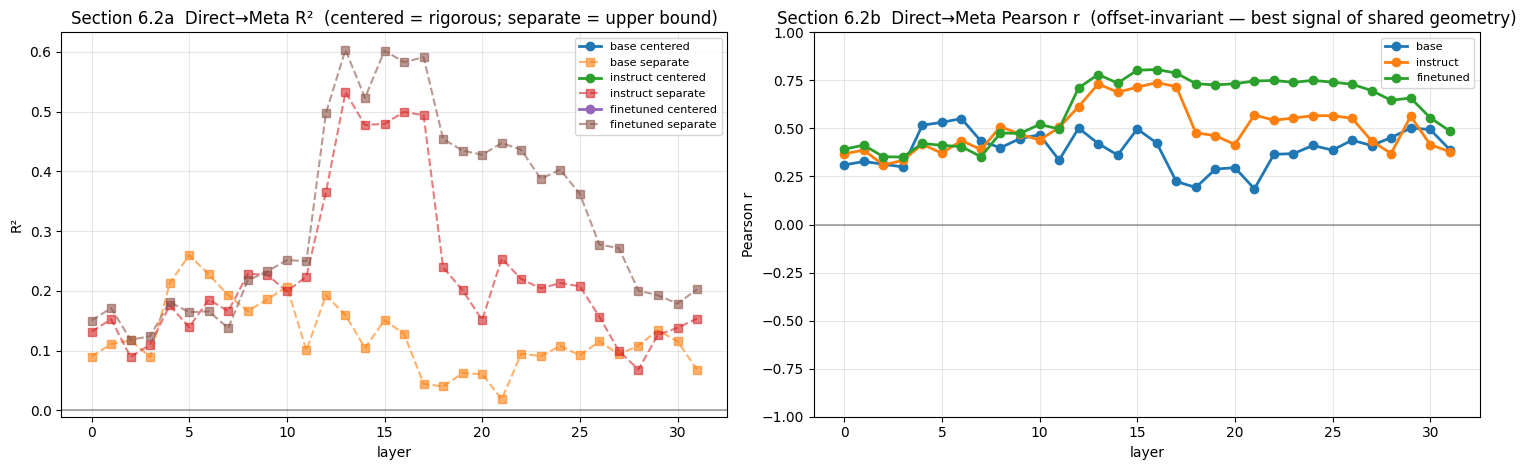


Direct→Meta entropy-probe transfer (centered / separate / pearson):
  [base]
    centered: not present in saved results.json (older run? — re-run to capture)
    separate: best=0.2598 at L5    median=0.1096
    pearson : best=0.5513 at L6    median=0.4052
  [instruct]
    centered: not present in saved results.json (older run? — re-run to capture)
    separate: best=0.5322 at L13    median=0.2000
    pearson : best=0.7385 at L16    median=0.4737
  [finetuned]
    centered: not present in saved results.json (older run? — re-run to capture)
    separate: best=0.6034 at L13    median=0.2615
    pearson : best=0.8065 at L16    median=0.6777


In [21]:
# Plot 2: direct→meta TRANSFER R². Three scaling strategies — Pearson is the most diagnostic
# of "is the geometry preserved?" because it ignores the absolute offset shift between prompts.

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for r in RUNS:
    if not r.results: continue
    pr = r.results.get('probe_results') or {}
    layers = sorted(int(k) for k in pr)

    d2m_centered = [pr[str(l)].get('direct_to_meta_centered', {}).get('r2', np.nan) for l in layers]
    d2m_separate = [pr[str(l)].get('direct_to_meta_fixed',    {}).get('r2', np.nan) for l in layers]
    d2m_pearson  = [pr[str(l)].get('direct_to_meta',          {}).get('pearson', np.nan) for l in layers]

    axes[0].plot(layers, d2m_centered, 'o-', linewidth=2, label=f'{r.label} centered')
    axes[0].plot(layers, d2m_separate, 's--', alpha=0.6, label=f'{r.label} separate')
    axes[1].plot(layers, d2m_pearson,  'o-', linewidth=2, label=f'{r.label}')

axes[0].axhline(0, color='black', alpha=0.3)
axes[0].set_title('Section 6.2a  Direct→Meta R²  (centered = rigorous; separate = upper bound)')
axes[0].set_xlabel('layer'); axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='black', alpha=0.3)
axes[1].set_title('Section 6.2b  Direct→Meta Pearson r  (offset-invariant — best signal of shared geometry)')
axes[1].set_xlabel('layer'); axes[1].set_ylabel('Pearson r')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_ylim(-1, 1)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nDirect→Meta entropy-probe transfer (centered / separate / pearson):")
for r in RUNS:
    if not r.results: continue
    pr = r.results.get('probe_results') or {}
    layers = sorted(int(k) for k in pr)
    cen = [pr[str(l)].get('direct_to_meta_centered', {}).get('r2', np.nan) for l in layers]
    sep = [pr[str(l)].get('direct_to_meta_fixed',    {}).get('r2', np.nan) for l in layers]
    prn = [pr[str(l)].get('direct_to_meta',          {}).get('pearson', np.nan) for l in layers]
    print(f"  [{r.label}]")
    for name, vals in [("centered", cen), ("separate", sep), ("pearson", prn)]:
        arr = np.asarray(vals, dtype=float)
        if np.all(np.isnan(arr)):
            print(f"    {name:8s}: not present in saved results.json (older run? — re-run to capture)")
            continue
        bl = layers[int(np.nanargmax(arr))]
        print(f"    {name:8s}: best={float(np.nanmax(arr)):.4f} at L{bl}    median={float(np.nanmedian(arr)):.4f}")


In [22]:
# Bonus: best-layer summary table per run.
rows = []
for r in RUNS:
    if not r.results: continue
    pr = r.results.get('probe_results') or {}
    if not pr: continue
    by_layer = {int(l): pr[l] for l in pr}
    layers = sorted(by_layer)
    best_d2d_l = max(layers, key=lambda l: by_layer[l]['direct_to_direct']['test_r2'])
    best_d2m_c = max(layers, key=lambda l: by_layer[l].get('direct_to_meta_centered', {}).get('r2', -1e9))
    best_d2m_s = max(layers, key=lambda l: by_layer[l].get('direct_to_meta_fixed', {}).get('r2', -1e9))
    rows.append({
        'run': r.label,
        'best_d2d_layer': best_d2d_l,
        'best_d2d_R²':    by_layer[best_d2d_l]['direct_to_direct']['test_r2'],
        'best_d2m_layer (centered)': best_d2m_c,
        'best_d2m_R² (centered)':    by_layer[best_d2m_c].get('direct_to_meta_centered', {}).get('r2', np.nan),
        'best_d2m_layer (separate)': best_d2m_s,
        'best_d2m_R² (separate)':    by_layer[best_d2m_s].get('direct_to_meta_fixed', {}).get('r2', np.nan),
    })
pd.DataFrame(rows).round(4)


,run,best_d2d_layer,best_d2d_R²,best_d2m_layer (centered),best_d2m_R² (centered),best_d2m_layer (separate),best_d2m_R² (separate)
0,base,29,0.9771,0,NaN,5,0.2598
1,instruct,24,0.9329,0,NaN,13,0.5322
2,finetuned,25,0.9725,0,NaN,13,0.6034


### Section 6.3  MC-answer probe (predicting the model's chosen letter)

This is a **second** probe, completely independent of the entropy probe in §6.1/§6.2. We train a 4-class LogisticRegression to predict which of A/B/C/D the model picked, from direct activations.

**Reading**:
- **D→D accuracy** = "can a linear probe read the model's chosen letter from its own activations?" Should peak well above chance (0.25) at some layer.
- **D→M accuracy** = "does that same probe still read the right letter from META activations (the confidence prompt)?". If it stays close to D→D, the model's answer-choice representation is preserved across the two prompts. If it drops to chance, the meta prompt has erased the answer information.
- **Chance line at 0.25** for the 4-class baseline.

The headline introspection question for THIS probe: does the model maintain its identification of the correct answer (or its chosen answer) when it switches to verbalising confidence? If yes → "I picked D, and now I'm asked how confident I am about D" — the meta prompt is informed by the same answer state.


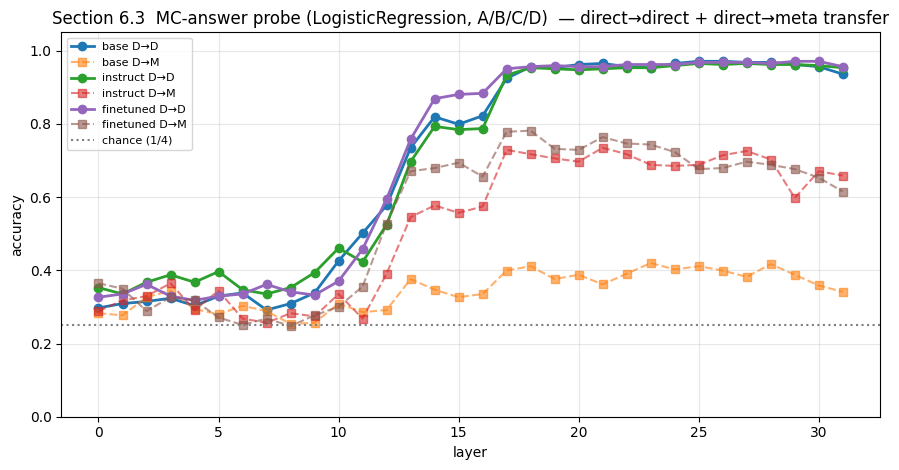


MC-answer probe (4-class LogisticRegression):
  [base]
    D→D best acc=0.9708 at L25    chance=0.250    median=0.8207
    D→M best acc=0.4198 at L23                       median=0.3455
  [instruct]
    D→D best acc=0.9650 at L25    chance=0.250    median=0.7901
    D→M best acc=0.7347 at L21                       median=0.5758
  [finetuned]
    D→D best acc=0.9708 at L29    chance=0.250    median=0.8819
    D→M best acc=0.7813 at L18                       median=0.6633


In [23]:
# MC-answer probe — direct→direct accuracy per layer, plus chance line.
fig, ax = plt.subplots(figsize=(9, 4.8))
for r in RUNS:
    if not r.results: continue
    mc = r.results.get('mc_answer_probe') or {}
    if not mc: continue
    layers = sorted(int(k) for k in mc)
    d2d = [mc[str(l)]['d2d_accuracy'] for l in layers]
    d2m = [mc[str(l)]['d2m_accuracy'] for l in layers]
    ax.plot(layers, d2d, 'o-', linewidth=2, label=f'{r.label} D→D')
    ax.plot(layers, d2m, 's--', alpha=0.6, label=f'{r.label} D→M')
ax.axhline(0.25, color='gray', linestyle=':', label='chance (1/4)')
ax.set_xlabel('layer'); ax.set_ylabel('accuracy')
ax.set_title('Section 6.3  MC-answer probe (LogisticRegression, A/B/C/D)  — direct→direct + direct→meta transfer')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nMC-answer probe (4-class LogisticRegression):")
for r in RUNS:
    if not r.results: continue
    mc = r.results.get('mc_answer_probe') or {}
    if not mc: continue
    layers = sorted(int(k) for k in mc)
    d2d = [mc[str(l)]['d2d_accuracy'] for l in layers]
    d2m = [mc[str(l)]['d2m_accuracy'] for l in layers]
    bd = layers[int(np.argmax(d2d))]; bm = layers[int(np.argmax(d2m))]
    print(f"  [{r.label}]")
    print(f"    D→D best acc={max(d2d):.4f} at L{bd}    chance=0.250    median={np.median(d2d):.4f}")
    print(f"    D→M best acc={max(d2m):.4f} at L{bm}                       median={np.median(d2m):.4f}")


---

## Paper Ready Figures

Cleaned versions of the figures used in the paper. Everything else in this notebook is appendix material.


### Figure 2 — Stated confidence increasingly tracks answer certainty

Behavioural evidence: Spearman ρ between stated confidence and the entropy-derived certainty signal (-H_direct) on each run. Higher = stated confidence varies in lock-step with the model's own answer-distribution certainty.


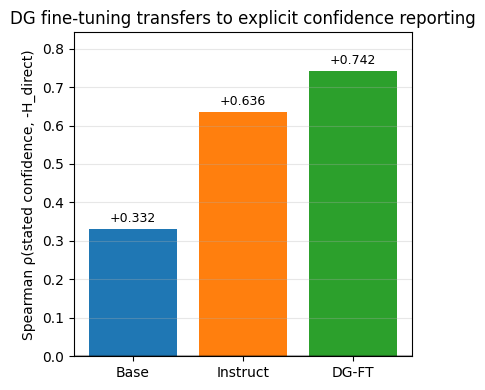


Spearman ρ(-entropy, stated_confidence) per run:
  Base                           +0.3316
  Instruct                       +0.6355
  DG-FT                          +0.7423


In [28]:
# Figure 2 — Spearman ρ(stated confidence, -H_direct) across runs.
# Bar plot is intentionally simple; caption notes that DG-FT was fine-tuned on
# Delegate Game but evaluated on ECT.
_PAPER_LABELS = {'base': 'Base', 'instruct': 'Instruct', 'finetuned': 'DG-FT'}
def _paper_label(lab):
    return _PAPER_LABELS.get(lab, lab)

fig, ax = plt.subplots(figsize=(max(4, 1.4 * len(RUNS)), 4))
labels = [_paper_label(r.label) for r in RUNS]
rhos = []
for r in RUNS:
    pd_ = r.paired
    ent = np.asarray(pd_['direct_metrics']['entropy'])
    sc = np.asarray(pd_['stated_confidence_numeric'], float)
    m = ~np.isnan(ent) & ~np.isnan(sc)
    if m.sum() < 10:
        rhos.append(np.nan); continue
    rho, _ = spearmanr(-ent[m], sc[m])
    rhos.append(float(rho))
bars = ax.bar(labels, rhos, color=[plt.cm.tab10(i) for i in range(len(RUNS))])
for bar, rho in zip(bars, rhos):
    if not np.isnan(rho):
        ax.text(bar.get_x() + bar.get_width() / 2, rho + (0.01 if rho >= 0 else -0.03),
                f"{rho:+.3f}", ha='center',
                va='bottom' if rho >= 0 else 'top', fontsize=9)
ax.axhline(0, color='black', alpha=0.3)
ax.set_ylim(min(0, min([r for r in rhos if not np.isnan(r)] or [0]) - 0.05),
            max([r for r in rhos if not np.isnan(r)] or [0.5]) + 0.1)
ax.set_ylabel('Spearman ρ(stated confidence, -H_direct)')
ax.set_title('DG fine-tuning transfers to explicit confidence reporting')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---- text output ----
print("\nSpearman ρ(-entropy, stated_confidence) per run:")
for lab, rho in zip(labels, rhos):
    print(f"  {lab:30s} {rho:+.4f}" if not np.isnan(rho) else f"  {lab:30s} (insufficient data)")


### Figure 3 — Mechanistic evidence (2 panels)

**Panel A.** Per-layer cosine between the certainty direction and the confidence-report direction (both contrastively defined activation-space directions; see methods). Higher = the same residual-stream axis encodes "I'm uncertain about this answer" and "I'm not very confident", elicited from two different prompts.

**Panel B.** Direct→Meta entropy-probe transfer, scored by Pearson r. The probe is trained on direct-task activations and applied to meta-prompt (confidence-report) activations; Pearson is offset-invariant, so it answers "do the predictions linearly track true entropy under the meta prompt?".


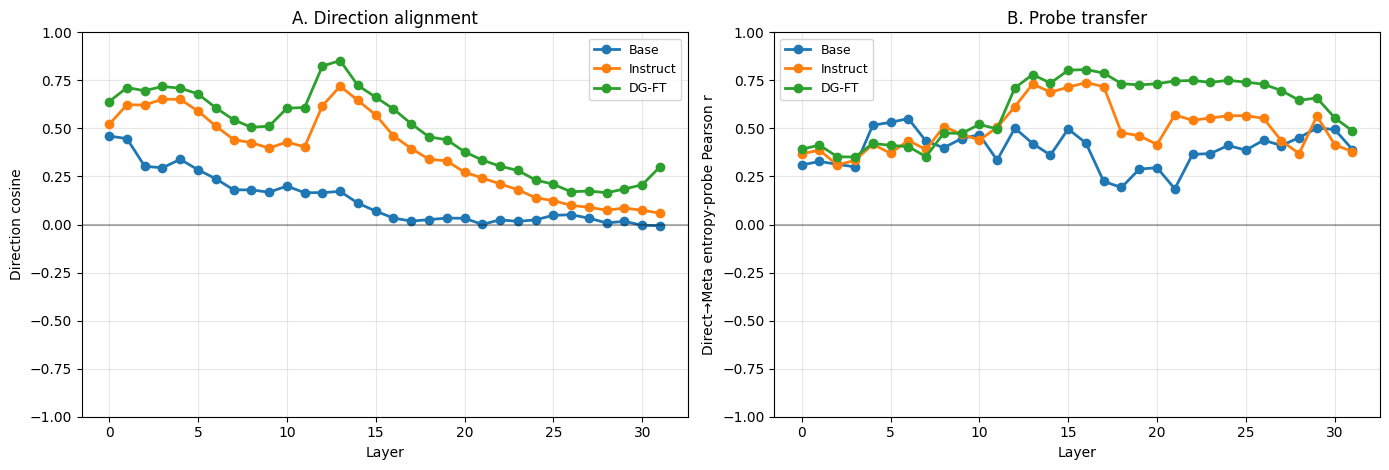

In [29]:
# Figure 3 — Panels A and B (paper-ready combined mechanistic figure).
# Long descriptions live in the caption; in-plot titles are kept short.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# ---- Panel A: per-layer cosine(certainty, confidence-report) ----
axA = axes[0]
for r in RUNS:
    ec, sc = r.entropy_contrast_dirs(), r.stated_conf_contrast_dirs()
    if ec is None or sc is None:
        continue
    ec_arr, layers = _stack_layers(ec)
    sc_arr, _ = _stack_layers(sc)
    # entropy_contrast points low-confidence ↑; flip sign so 'certainty direction' aligns
    # with high-confidence ↑, matching the confidence-report direction.
    cos = np.array([_cosine(-ec_arr[i], sc_arr[i]) for i in range(len(layers))])
    axA.plot(layers, cos, 'o-', linewidth=2, label=_paper_label(r.label))
axA.axhline(0, color='black', alpha=0.3)
axA.set_xlabel('Layer')
axA.set_ylabel('Direction cosine')
axA.set_title('A. Direction alignment')
axA.legend(fontsize=9); axA.grid(alpha=0.3)
axA.set_ylim(-1, 1)

# ---- Panel B: Direct→Meta entropy-probe Pearson r ----
axB = axes[1]
for r in RUNS:
    if not r.results: continue
    pr = r.results.get('probe_results') or {}
    if not pr: continue
    layers = sorted(int(k) for k in pr)
    pearson = [pr[str(l)].get('direct_to_meta', {}).get('pearson', np.nan) for l in layers]
    axB.plot(layers, pearson, 'o-', linewidth=2, label=_paper_label(r.label))
axB.axhline(0, color='black', alpha=0.3)
axB.set_xlabel('Layer')
axB.set_ylabel('Direct→Meta entropy-probe Pearson r')
axB.set_title('B. Probe transfer')
axB.legend(fontsize=9); axB.grid(alpha=0.3)
axB.set_ylim(-1, 1)

plt.tight_layout(); plt.show()
